# @author: Dr. Manish Yadav
### Email: manish.yadav@tu-berlin.de

This code contains the functions for "Emergent E-I Structure in Performance-Evolved Reservoir Networks of
Neuronal Population Dynamics" by Manish Yadav.

In [1]:
import numpy as np
import time
import PDNE_Functions as PDNE
import Tasks
import os
import matplotlib.pyplot as plt
import networkx as nx
import pickle

from RC_Funcs import *
from Tasks import *
from PDNE_Functions import *
from Plots import *

# 1. Define paramerters and Load WC Data

In [2]:
###### Model preparation ##############################
Informed_Growth = 'Yes' ###'No'
Delete_Nodes = 'Yes' ### 'No'  ##### Informed node deletion with 'Yes' or 'No'
InpNodeType = 0  ###### 0-> New node can be input node for other inputs as well (in multiple tasks) with Prob P_inp, 1-> Strictly exclusive to each task
OutNodeType = 0  ###### 0-> New node can be output node for other outputs as well (in multiple tasks) with Prob P_inp, 1-> Strictly exclusive to each task

##### Model Parameters ##################################
NodesDel_Percent = 20 ##### Least no. of attempts to delete nodes 
Max_AddSteps=25 ##### No. of steps the node addition function attempt, if in all steps no new node is added, t+=1

###make inital random seed network 
Nodes_init = np.array([10, 15, 25])
RandNet_init = [60, 100]
Ks= 1 
eig_rhos = 0.2 

# Net_Init = RandNetGenerator(Ks, Na, eig_rhos)

### Psi = Prob of in or out connections
### P_inp or P_out is the prob. that a new node is also an input node or not. [0, 1], 0(1)-> No(all) new nodes are inp/out nodes
MaxNewLinks = 5 
Psi=0.5  
Spectral_radius= 0.2 
T = 500 #200 ;  #### Max iterations
T_plot=25; RC_Reps=1
NetProps = [NodesDel_Percent, Max_AddSteps, MaxNewLinks, Psi, Spectral_radius]
####### Inputs and tasks###########################################################
P_inp=0.5; P_out= 1 - P_inp; 
#### Scores_Names#################################################################
Scores_Names=['NMSE train', 'NMSE pred']

####Training params#########################################################
beta = 5e-10 

Original Train Inp and Out Plot:
(6, 1, 200) (6, 2, 200) (6, 1, 200) (6, 2, 200)


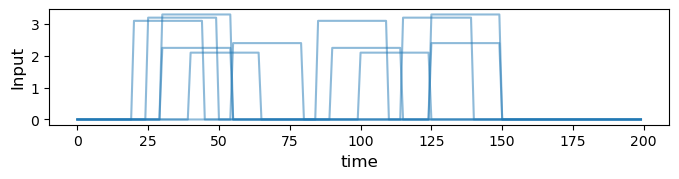

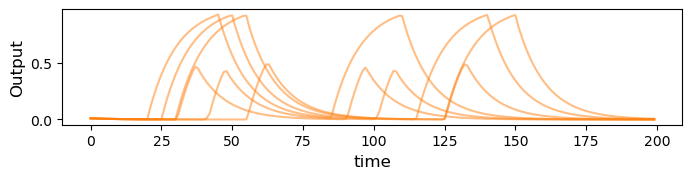

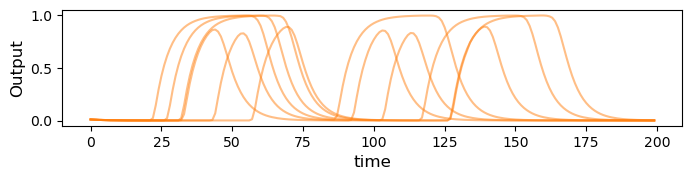

Original WC neuron Predict Inputs shape: (18, 1, 200) Predict Outputs shape: (18, 2, 200)


In [3]:
####Select the Task here#########################################################
TaskType = 'WC_Neuron'         ####Choices: 'SinCos' #'Chaos' #'VDP' #'NARMA'

####WC Neuron Task###################################################################
if TaskType=='WC_Neuron':
    alpha = 0.2 
    N_I=1; N_O=2
    
    ###g_scale random beteen [0.1, 1.0] for each node in the initial network
    # g_scale_init = list(np.random.uniform(0.01, 1.0, size=Net_Init.shape[0]))
        
    Npts_U = 3000; Transs=10
    Delta_err= 0.0075 
    ### Desired Error and error precision (rounding off error digits for comparision)
    Err_precision= 6

    ###current directory
    try:
        DataDir = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/'
        SaveDir1 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[0]) #os.path.dirname(os.path.abspath(__file__))
        SaveDir2 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[1]) #os.path.dirname(os.path.abspath(__file__))
        SaveDir3 = 'D:/Work/TU-Berlin/Personal/work/Cell_DigitalTwin/WC_Neuron/Data2/Net_Init{}'.format(Nodes_init[2]) #os.path.dirname(os.path.abspath(__file__))
    except NameError:
        DataDir = os.getcwd()
    ###Data directory
    InpProps = [DataDir, 'Train']


######################################################################################  
#### Test Inp_Out Plot
print('Original Train Inp and Out Plot:')
Inps_O, Outs_O, Inps_test_O, Outs_test_O = Tasks.InpGenerate(TaskType, N_I, Npts_U, InpProps)

print(Inps_O.shape, Outs_O.shape, Inps_test_O.shape, Outs_test_O.shape)

if TaskType=='WC_Neuron':
    Tasks.InPlot_with_batches(Inps_O, Outs_O)
else:
    Tasks.InpPlot(Inps_O, Outs_O, N_I) 

###also get prediction data
InpProps_pred = [DataDir, 'Predict']
Inps_pred_Diverse_O, Outs_pred_Diverse_O = Tasks.InpGenerate('WC_Neuron', N_I, Npts_U, InpProps_pred)
print('Original WC neuron Predict Inputs shape:', Inps_pred_Diverse_O.shape, 'Predict Outputs shape:', Outs_pred_Diverse_O.shape)

In [130]:
######### Save Directory
ModelDir1 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[0])
ModelDir2 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[1])
ModelDir3 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(Nodes_init[2])
RandNet_Dir1 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(RandNet_init[0])
RandNet_Dir2 = 'D:\\Work\\TU-Berlin\\Personal\\work\\Cell_DigitalTwin\\WC_Neuron\\Data2\\Net_Init{}'.format(RandNet_init[1])

###loading model data
def read_gpickle_compat(file_path):
    with open(file_path, 'rb') as f:
        try:
            return pickle.load(f)
        except ValueError as e:
            # Pickle protocol 5 requires Python >= 3.8. Fallback for older kernels.
            if 'unsupported pickle protocol: 5' not in str(e):
                raise
            f.seek(0)
            try:
                import pickle5 as pickle5_module
            except ImportError as ie:
                raise RuntimeError(
                    "This file uses pickle protocol 5. Use Python 3.8+ kernel or install 'pickle5'."
                ) from ie
            return pickle5_module.load(f)
        
def LoadData(SaveDir, TaskType, Nodes_init, ModelRep, RandNet='False'):
    
    NetMsr = np.load(os.path.join(SaveDir,'{:}_{:d}_NetMeasures_Rp{:d}.npy'.format(TaskType, Nodes_init, ModelRep))) 
    Scores = np.load(os.path.join(SaveDir,'{:}_{:d}_Scores_Rp{:d}.npy'.format(TaskType, Nodes_init, ModelRep))) 
    AllInpsNodes = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_InpsNodes_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    AllOutsNodes = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_OutsNodes_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    AllGraphs = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Graphs_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    All_g_scales = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_g_scales_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    Train_ResStates = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Train_ResStates_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    Pred_ResStates = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Pred_ResStates_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    
    # if RandNet==True:
    W_outs = read_gpickle_compat(os.path.join(SaveDir,'{:}_{:d}_Train_W_outs_Rp{:d}.gpickle'.format(TaskType, Nodes_init, ModelRep)))
    return NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates, W_outs

    # return NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates
   

###load final model data for model repetition 0
def LoadFinalModel(SaveDir, TaskType, Nodes_init, ModelRep, FinalModelName='Final'):
    G = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Graph_Rp{ModelRep:d}.gpickle"))
    g_scale = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_g_scale_Rp{ModelRep:d}.gpickle"))
    InpsNodes = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_InpsNodes_Rp{ModelRep:d}.gpickle"))
    OutsNodes = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_OutsNodes_Rp{ModelRep:d}.gpickle"))
    W_outs = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_W_outs_Rp{ModelRep:d}.gpickle"))
    Winps = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Winps_Rp{ModelRep:d}.gpickle"))
    Predictions = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Predictions_Rp{ModelRep:d}.gpickle"))
    Train_ResStates = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Train_ResStates_Rp{ModelRep:d}.gpickle"))
    Pred_ResStates = read_gpickle_compat(os.path.join(SaveDir, f"{TaskType}_{Nodes_init}_{FinalModelName}_Pred_ResStates_Rp{ModelRep:d}.gpickle"))
    return G, g_scale, InpsNodes, OutsNodes, W_outs[0], Winps[0], Predictions, Train_ResStates, Pred_ResStates

In [ ]:
###collect the data for all Model Repetitions 
Model_Reps= 10 #10
Model_Rand_Reps = 15

def LoadFinalDiversePredModel(ModelDir, TaskType, Nodes_init, Model_Reps, RandNet='False'):
     ###collect the data for all Model Repetitions
     NetMsr_list = [];  Scores_list = [];   AllInpsNodes_list = []
     AllOutsNodes_list = [];   AllGraphs_list = [];   All_g_scales_list = []
     All_Train_ResStates = []; All_Pred_ResStates = []
     All_W_outs = []
     for ModelRep in range(Model_Reps):
          if RandNet==True:
               NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates, W_outs = LoadData(ModelDir, TaskType, Nodes_init, ModelRep, RandNet)
               All_W_outs.append(W_outs)
          else:
               NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates\
                 = LoadData(ModelDir, TaskType, Nodes_init, ModelRep)
               
          NetMsr_list.append(NetMsr); Scores_list.append(Scores)
          AllInpsNodes_list.append(AllInpsNodes); AllOutsNodes_list.append(AllOutsNodes)
          AllGraphs_list.append(AllGraphs); All_g_scales_list.append(All_g_scales)
          All_Train_ResStates.append(Train_ResStates); All_Pred_ResStates.append(Pred_ResStates)

     # NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales = LoadData(ModelDir, TaskType, Nodes_init, 0)
     print('NetMsr', NetMsr.shape, 'Scores', Scores.shape, 'AllInpsNodes', len(AllInpsNodes), 'AllOutsNodes', len(AllOutsNodes), 'AllGraphs', len(AllGraphs), 'All_g_scales', len(All_g_scales))
     print('Train_ResStates:', len(Train_ResStates), len(Train_ResStates[0]), len(Train_ResStates[0][0]), len(Train_ResStates[0][0][0]), 'Pred_ResStates:', len(Pred_ResStates))
     ###similarly, load final model data for all Model Repetitions
     FM_tst_NetMsr = [];  FM_tst_Scores = []
     FM_tst_InpsNodes = [];   FM_tst_OutsNodes = []
     FM_tst_Graphs = [];  FM_tst_g_scales = []
     FM_tst_W_outs = [];   FM_tst_Winps = []
     FM_tst_Predictions = []
     FM_train_ResStates=[]; FM_pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst, Train_ResStates_tst, Pred_ResStates_tst\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final')
          FM_tst_NetMsr.append(G.number_of_nodes())
          FM_tst_Scores.append(None)  ###Scores not saved separately for final model, can be calculated if needed
          FM_tst_InpsNodes.append(InpsNodes_tst)
          FM_tst_OutsNodes.append(OutsNodes_tst)
          FM_tst_Graphs.append(G)
          FM_tst_g_scales.append(g_scale_tst)
          FM_tst_W_outs.append(W_outs_tst)
          FM_tst_Winps.append(Winps_tst)
          FM_tst_Predictions.append(Predictions_tst)
          FM_train_ResStates.append(Train_ResStates_tst)
          FM_pred_ResStates.append(Pred_ResStates_tst)

     FM_tst_Predictions = np.array(FM_tst_Predictions)[:,0,:,:,:]

     # G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst = LoadFinalModel(ModelDir, TaskType, 0, 'Final')
     # print('Final Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
     #        W_outs shape {}, Winps shape {}'.format(G.number_of_nodes(), len(g_scale_tst), len(InpsNodes_tst), len(OutsNodes_tst), len(W_outs_tst), len(Winps_tst)))
     # print('Predictions shape:', Predictions_tst.shape)

     ###similarly, load final diverse prediction model data for all Model Repetitions
     FM_divPreds_NetMsr = [];  FM_divPreds_Scores = []
     FM_divPreds_InpsNodes = [];  FM_divPreds_OutsNodes = []
     FM_divPreds_Graphs = [];  FM_divPreds_g_scales = []
     FM_divPreds_W_outs = [];  FM_divPreds_Winps = []
     FM_divPreds_Predictions = []
     FM_divPreds_Train_ResStates = [];  FM_divPreds_Pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f, Train_ResStates_f, Pred_ResStates_f\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final_DiversePredictions')
          FM_divPreds_NetMsr.append(G_f.number_of_nodes())
          FM_divPreds_Scores.append(None)  ###Scores not saved separately for final diverse prediction model, can be calculated if needed
          FM_divPreds_InpsNodes.append(InpsNodes_f)
          FM_divPreds_OutsNodes.append(OutsNodes_f)
          FM_divPreds_Graphs.append(G_f)
          FM_divPreds_g_scales.append(g_scale_f)
          FM_divPreds_W_outs.append(W_outs_f)
          FM_divPreds_Winps.append(Winps_f)
          FM_divPreds_Predictions.append(Predictions_f)
          FM_divPreds_Train_ResStates.append(Train_ResStates_f)
          FM_divPreds_Pred_ResStates.append(Pred_ResStates_f)

     FM_divPreds_Predictions = np.array(FM_divPreds_Predictions)[:,0,:,:,:]

     if RandNet == True:
          return NetMsr_list, Scores_list, AllInpsNodes_list, AllOutsNodes_list, AllGraphs_list, All_g_scales_list, \
               All_Train_ResStates, All_Pred_ResStates, All_W_outs, \
               FM_tst_NetMsr, FM_tst_Scores, FM_tst_InpsNodes, FM_tst_OutsNodes, FM_tst_Graphs, FM_tst_g_scales, \
               FM_train_ResStates, FM_pred_ResStates, \
               FM_tst_W_outs, FM_tst_Winps, FM_tst_Predictions, FM_divPreds_NetMsr, FM_divPreds_Scores, FM_divPreds_InpsNodes, \
               FM_divPreds_Train_ResStates, FM_divPreds_Pred_ResStates, \
               FM_divPreds_OutsNodes, FM_divPreds_Graphs, FM_divPreds_g_scales, FM_divPreds_W_outs, FM_divPreds_Winps, FM_divPreds_Predictions
     else:
          return NetMsr_list, Scores_list, AllInpsNodes_list, AllOutsNodes_list, AllGraphs_list, All_g_scales_list, \
          All_Train_ResStates, All_Pred_ResStates, \
          FM_tst_NetMsr, FM_tst_Scores, FM_tst_InpsNodes, FM_tst_OutsNodes, FM_tst_Graphs, FM_tst_g_scales, \
          FM_train_ResStates, FM_pred_ResStates, \
          FM_tst_W_outs, FM_tst_Winps, FM_tst_Predictions, FM_divPreds_NetMsr, FM_divPreds_Scores, FM_divPreds_InpsNodes, \
          FM_divPreds_Train_ResStates, FM_divPreds_Pred_ResStates, \
          FM_divPreds_OutsNodes, FM_divPreds_Graphs, FM_divPreds_g_scales, FM_divPreds_W_outs, FM_divPreds_Winps, FM_divPreds_Predictions

###load final prediction data 'final diverseprediction' models
# G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f = LoadFinalModel(ModelDir, TaskType, Nodes_init, 0, 'Final_DiversePredictions')
# print('Final Diverse Prediction Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
#        W_outs shape {}, Winps shape {}'.format(G_f.number_of_nodes(), len(g_scale_f), len(InpsNodes_f), len(OutsNodes_f), len(W_outs_f), len(Winps_f))) 
# print('Final Diverse Predictions shape:', Predictions_f.shape)


###calling the function for Net_Init[0]

NetMsr_list0, Scores_list0, AllInpsNodes_list0, AllOutsNodes_list0, AllGraphs_list0, All_g_scales_list0, \
All_Train_ResStates0, All_Pred_ResStates0, \
FM_tst_NetMsr0, FM_tst_Scores0, FM_tst_InpsNodes0, FM_tst_OutsNodes0, FM_tst_Graphs0, FM_tst_g_scales0, \
FM_train_ResStates0, FM_pred_ResStates0, \
FM_tst_W_outs0, FM_tst_Winps0, FM_tst_Predictions0, FM_divPreds_NetMsr0, FM_divPreds_Scores0, FM_divPreds_InpsNodes0, \
FM_divPreds_Train_ResStates0, FM_divPreds_Pred_ResStates0, \
FM_divPreds_OutsNodes0, FM_divPreds_Graphs0, FM_divPreds_g_scales0, FM_divPreds_W_outs0, FM_divPreds_Winps0, FM_divPreds_Predictions0\
= LoadFinalDiversePredModel(ModelDir1, TaskType, Nodes_init[0], Model_Reps)

NetMsr_list1, Scores_list1, AllInpsNodes_list1, AllOutsNodes_list1, AllGraphs_list1, All_g_scales_list1, \
All_Train_ResStates1, All_Pred_ResStates1, \
FM_tst_NetMsr1, FM_tst_Scores1, FM_tst_InpsNodes1, FM_tst_OutsNodes1, FM_tst_Graphs1, FM_tst_g_scales1, \
FM_train_ResStates1, FM_pred_ResStates1, \
FM_tst_W_outs1, FM_tst_Winps1, FM_tst_Predictions1, FM_divPreds_NetMsr1, FM_divPreds_Scores1, FM_divPreds_InpsNodes1, \
FM_divPreds_Train_ResStates1, FM_divPreds_Pred_ResStates1, \
FM_divPreds_OutsNodes1, FM_divPreds_Graphs1, FM_divPreds_g_scales1, FM_divPreds_W_outs1, FM_divPreds_Winps1, FM_divPreds_Predictions1\
= LoadFinalDiversePredModel(ModelDir2, TaskType, Nodes_init[1], Model_Reps)

NetMsr_list2, Scores_list2, AllInpsNodes_list2, AllOutsNodes_list2, AllGraphs_list2, All_g_scales_list2, \
All_Train_ResStates2, All_Pred_ResStates2, \
FM_tst_NetMsr2, FM_tst_Scores2, FM_tst_InpsNodes2, FM_tst_OutsNodes2, FM_tst_Graphs2, FM_tst_g_scales2, \
FM_train_ResStates2, FM_pred_ResStates2, \
FM_tst_W_outs2, FM_tst_Winps2, FM_tst_Predictions2, FM_divPreds_NetMsr2, FM_divPreds_Scores2, FM_divPreds_InpsNodes2, \
FM_divPreds_Train_ResStates2, FM_divPreds_Pred_ResStates2, \
FM_divPreds_OutsNodes2, FM_divPreds_Graphs2, FM_divPreds_g_scales2, FM_divPreds_W_outs2, FM_divPreds_Winps2, FM_divPreds_Predictions2\
= LoadFinalDiversePredModel(ModelDir3, TaskType, Nodes_init[2], Model_Reps)


####joining All reservoir states
All_Train_ResStates = All_Train_ResStates0 + All_Train_ResStates1 + All_Train_ResStates2
All_Pred_ResStates = All_Pred_ResStates0 + All_Pred_ResStates1 + All_Pred_ResStates2


###joining the FM_resStates
FM_train_ResStates = FM_train_ResStates0 + FM_train_ResStates1 + FM_train_ResStates2
print(len(FM_train_ResStates), len(FM_train_ResStates[0]), len(FM_train_ResStates[0][0]), len(FM_train_ResStates[0][0][0]))

FM_pred_ResStates = FM_pred_ResStates0 + FM_pred_ResStates1 + FM_pred_ResStates2
print(len(FM_pred_ResStates), len(FM_pred_ResStates[0]), len(FM_pred_ResStates[0][0]), len(FM_pred_ResStates[0][0][0]))


####randnet data loading
NetMsr_list_R0, Scores_list_R0, AllInpsNodes_list_R0, AllOutsNodes_list_R0, AllGraphs_list_R0, All_g_scales_list_R0, \
All_Train_ResStates_R0, All_Pred_ResStates_R0, All_W_outs_R0, \
FM_tst_NetMsr_R0, FM_tst_Scores_R0, FM_tst_InpsNodes_R0, FM_tst_OutsNodes_R0, FM_tst_Graphs_R0, FM_tst_g_scales_R0, \
FM_train_ResStates_R0, FM_pred_ResStates_R0, \
FM_tst_W_outs_R0, FM_tst_Winps_R0, FM_tst_Predictions_R0, FM_divPreds_NetMsr_R0, FM_divPreds_Scores_R0, FM_divPreds_InpsNodes_R0, \
FM_divPreds_Train_ResStates_R0, FM_divPreds_Pred_ResStates_R0, \
FM_divPreds_OutsNodes_R0, FM_divPreds_Graphs_R0, FM_divPreds_g_scales_R0, FM_divPreds_W_outs_R0, FM_divPreds_Winps_R0, FM_divPreds_Predictions_R0\
= LoadFinalDiversePredModel(RandNet_Dir1, TaskType, RandNet_init[0], Model_Rand_Reps, RandNet=True)

NetMsr_list_R1, Scores_list_R1, AllInpsNodes_list_R1, AllOutsNodes_list_R1, AllGraphs_list_R1, All_g_scales_list_R1, \
All_Train_ResStates_R1, All_Pred_ResStates_R1, All_W_outs_R1, \
FM_tst_NetMsr_R1, FM_tst_Scores_R1, FM_tst_InpsNodes_R1, FM_tst_OutsNodes_R1, FM_tst_Graphs_R1, FM_tst_g_scales_R1, \
FM_train_ResStates_R1, FM_pred_ResStates_R1, \
FM_tst_W_outs_R1, FM_tst_Winps_R1, FM_tst_Predictions_R1, FM_divPreds_NetMsr_R1, FM_divPreds_Scores_R1, FM_divPreds_InpsNodes_R1, \
FM_divPreds_Train_ResStates_R1, FM_divPreds_Pred_ResStates_R1, \
FM_divPreds_OutsNodes_R1, FM_divPreds_Graphs_R1, FM_divPreds_g_scales_R1, FM_divPreds_W_outs_R1, FM_divPreds_Winps_R1, FM_divPreds_Predictions_R1\
= LoadFinalDiversePredModel(RandNet_Dir2, TaskType, RandNet_init[1], Model_Rand_Reps, RandNet=True)

print('rand net net measures list shape:', len(NetMsr_list_R0), 'rand net scores list shape:', len(Scores_list_R0),\
       'rand net AllInpsNodes list length:', len(AllInpsNodes_list_R0), 'rand net AllOutsNodes list length:', len(AllOutsNodes_list_R0),\
     'rand net AllGraphs list length:', len(AllGraphs_list_R0), 'rand net All_g_scales list length:', len(All_g_scales_list_R0))

####joining All reservoir states
All_Train_ResStates_R = All_Train_ResStates_R0 + All_Train_ResStates_R1
All_Pred_ResStates_R = All_Pred_ResStates_R0 + All_Pred_ResStates_R1

###keeping only the inital reservoir states
All_Train_ResStates_R = [r[0] for r in All_Train_ResStates_R]
All_Pred_ResStates_R = [r[0] for r in All_Pred_ResStates_R]

NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 500 AllOutsNodes 500 AllGraphs 501 All_g_scales 501
Train_ResStates: 4 10 6 200 Pred_ResStates: 4
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 166 AllOutsNodes 166 AllGraphs 167 All_g_scales 167
Train_ResStates: 2 15 6 200 Pred_ResStates: 2
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 147 AllOutsNodes 147 AllGraphs 148 All_g_scales 148
Train_ResStates: 2 25 6 200 Pred_ResStates: 2
30 95 6 200
30 95 6 200
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 60 6 200 Pred_ResStates: 2
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 100 6 200 Pred_ResStates: 2
rand net net measures list shape: 15 rand net scores list shape: 15 rand net AllInpsNodes list length: 15 rand net AllOutsNodes list length: 15 rand net AllGraphs list length: 15 rand net All_g_scales list length: 15


In [131]:
###collect the data for all Model Repetitions 
Model_Reps= 10 #10
Model_Rand_Reps = 15

def LoadFinalDiversePredModel(ModelDir, TaskType, Nodes_init, Model_Reps, RandNet='False'):
     ###collect the data for all Model Repetitions
     NetMsr_list = [];  Scores_list = [];   AllInpsNodes_list = []
     AllOutsNodes_list = [];   AllGraphs_list = [];   All_g_scales_list = []
     All_Train_ResStates = []; All_Pred_ResStates = []
     All_W_outs = []
     for ModelRep in range(Model_Reps):
          # if RandNet==True:
          NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates, W_outs = LoadData(ModelDir, TaskType, Nodes_init, ModelRep, RandNet)
          All_W_outs.append(W_outs)
          # else:
          #      NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales, Train_ResStates, Pred_ResStates\
          #        = LoadData(ModelDir, TaskType, Nodes_init, ModelRep)
               
          NetMsr_list.append(NetMsr); Scores_list.append(Scores)
          AllInpsNodes_list.append(AllInpsNodes); AllOutsNodes_list.append(AllOutsNodes)
          AllGraphs_list.append(AllGraphs); All_g_scales_list.append(All_g_scales)
          All_Train_ResStates.append(Train_ResStates); All_Pred_ResStates.append(Pred_ResStates)

     # NetMsr, Scores, AllInpsNodes, AllOutsNodes, AllGraphs, All_g_scales = LoadData(ModelDir, TaskType, Nodes_init, 0)
     print('NetMsr', NetMsr.shape, 'Scores', Scores.shape, 'AllInpsNodes', len(AllInpsNodes), 'AllOutsNodes', len(AllOutsNodes), 'AllGraphs', len(AllGraphs), 'All_g_scales', len(All_g_scales))
     print('Train_ResStates:', len(Train_ResStates), len(Train_ResStates[0]), len(Train_ResStates[0][0]), len(Train_ResStates[0][0][0]), 'Pred_ResStates:', len(Pred_ResStates))
     ###similarly, load final model data for all Model Repetitions
     FM_tst_NetMsr = [];  FM_tst_Scores = []
     FM_tst_InpsNodes = [];   FM_tst_OutsNodes = []
     FM_tst_Graphs = [];  FM_tst_g_scales = []
     FM_tst_W_outs = [];   FM_tst_Winps = []
     FM_tst_Predictions = []
     FM_train_ResStates=[]; FM_pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst, Train_ResStates_tst, Pred_ResStates_tst\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final')
          FM_tst_NetMsr.append(G.number_of_nodes())
          FM_tst_Scores.append(None)  ###Scores not saved separately for final model, can be calculated if needed
          FM_tst_InpsNodes.append(InpsNodes_tst)
          FM_tst_OutsNodes.append(OutsNodes_tst)
          FM_tst_Graphs.append(G)
          FM_tst_g_scales.append(g_scale_tst)
          FM_tst_W_outs.append(W_outs_tst)
          FM_tst_Winps.append(Winps_tst)
          FM_tst_Predictions.append(Predictions_tst)
          FM_train_ResStates.append(Train_ResStates_tst)
          FM_pred_ResStates.append(Pred_ResStates_tst)

     FM_tst_Predictions = np.array(FM_tst_Predictions)[:,0,:,:,:]

     # G, g_scale_tst, InpsNodes_tst, OutsNodes_tst, W_outs_tst, Winps_tst, Predictions_tst = LoadFinalModel(ModelDir, TaskType, 0, 'Final')
     # print('Final Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
     #        W_outs shape {}, Winps shape {}'.format(G.number_of_nodes(), len(g_scale_tst), len(InpsNodes_tst), len(OutsNodes_tst), len(W_outs_tst), len(Winps_tst)))
     # print('Predictions shape:', Predictions_tst.shape)

     ###similarly, load final diverse prediction model data for all Model Repetitions
     FM_divPreds_NetMsr = [];  FM_divPreds_Scores = []
     FM_divPreds_InpsNodes = [];  FM_divPreds_OutsNodes = []
     FM_divPreds_Graphs = [];  FM_divPreds_g_scales = []
     FM_divPreds_W_outs = [];  FM_divPreds_Winps = []
     FM_divPreds_Predictions = []
     FM_divPreds_Train_ResStates = [];  FM_divPreds_Pred_ResStates = []
     for ModelRep in range(Model_Reps):
          G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f, Train_ResStates_f, Pred_ResStates_f\
                 = LoadFinalModel(ModelDir, TaskType, Nodes_init, ModelRep, 'Final_DiversePredictions')
          FM_divPreds_NetMsr.append(G_f.number_of_nodes())
          FM_divPreds_Scores.append(None)  ###Scores not saved separately for final diverse prediction model, can be calculated if needed
          FM_divPreds_InpsNodes.append(InpsNodes_f)
          FM_divPreds_OutsNodes.append(OutsNodes_f)
          FM_divPreds_Graphs.append(G_f)
          FM_divPreds_g_scales.append(g_scale_f)
          FM_divPreds_W_outs.append(W_outs_f)
          FM_divPreds_Winps.append(Winps_f)
          FM_divPreds_Predictions.append(Predictions_f)
          FM_divPreds_Train_ResStates.append(Train_ResStates_f)
          FM_divPreds_Pred_ResStates.append(Pred_ResStates_f)

     FM_divPreds_Predictions = np.array(FM_divPreds_Predictions)[:,0,:,:,:]

     # if RandNet == True:
     return NetMsr_list, Scores_list, AllInpsNodes_list, AllOutsNodes_list, AllGraphs_list, All_g_scales_list, \
          All_Train_ResStates, All_Pred_ResStates, All_W_outs, \
          FM_tst_NetMsr, FM_tst_Scores, FM_tst_InpsNodes, FM_tst_OutsNodes, FM_tst_Graphs, FM_tst_g_scales, \
          FM_train_ResStates, FM_pred_ResStates, \
          FM_tst_W_outs, FM_tst_Winps, FM_tst_Predictions, FM_divPreds_NetMsr, FM_divPreds_Scores, FM_divPreds_InpsNodes, \
          FM_divPreds_Train_ResStates, FM_divPreds_Pred_ResStates, \
          FM_divPreds_OutsNodes, FM_divPreds_Graphs, FM_divPreds_g_scales, FM_divPreds_W_outs, FM_divPreds_Winps, FM_divPreds_Predictions
     # else:
     #      return NetMsr_list, Scores_list, AllInpsNodes_list, AllOutsNodes_list, AllGraphs_list, All_g_scales_list, \
     #      All_Train_ResStates, All_Pred_ResStates, \
     #      FM_tst_NetMsr, FM_tst_Scores, FM_tst_InpsNodes, FM_tst_OutsNodes, FM_tst_Graphs, FM_tst_g_scales, \
     #      FM_train_ResStates, FM_pred_ResStates, \
     #      FM_tst_W_outs, FM_tst_Winps, FM_tst_Predictions, FM_divPreds_NetMsr, FM_divPreds_Scores, FM_divPreds_InpsNodes, \
     #      FM_divPreds_Train_ResStates, FM_divPreds_Pred_ResStates, \
     #      FM_divPreds_OutsNodes, FM_divPreds_Graphs, FM_divPreds_g_scales, FM_divPreds_W_outs, FM_divPreds_Winps, FM_divPreds_Predictions

###load final prediction data 'final diverseprediction' models
# G_f, g_scale_f, InpsNodes_f, OutsNodes_f, W_outs_f, Winps_f, Predictions_f = LoadFinalModel(ModelDir, TaskType, Nodes_init, 0, 'Final_DiversePredictions')
# print('Final Diverse Prediction Model Loaded: Graph with {} nodes, g_scale {}, InpsNodes {}, OutsNodes {},\
#        W_outs shape {}, Winps shape {}'.format(G_f.number_of_nodes(), len(g_scale_f), len(InpsNodes_f), len(OutsNodes_f), len(W_outs_f), len(Winps_f))) 
# print('Final Diverse Predictions shape:', Predictions_f.shape)


###calling the function for Net_Init[0]

NetMsr_list0, Scores_list0, AllInpsNodes_list0, AllOutsNodes_list0, AllGraphs_list0, All_g_scales_list0, \
All_Train_ResStates0, All_Pred_ResStates0, All_Wouts0, \
FM_tst_NetMsr0, FM_tst_Scores0, FM_tst_InpsNodes0, FM_tst_OutsNodes0, FM_tst_Graphs0, FM_tst_g_scales0, \
FM_train_ResStates0, FM_pred_ResStates0, \
FM_tst_W_outs0, FM_tst_Winps0, FM_tst_Predictions0, FM_divPreds_NetMsr0, FM_divPreds_Scores0, FM_divPreds_InpsNodes0, \
FM_divPreds_Train_ResStates0, FM_divPreds_Pred_ResStates0, \
FM_divPreds_OutsNodes0, FM_divPreds_Graphs0, FM_divPreds_g_scales0, FM_divPreds_W_outs0, FM_divPreds_Winps0, FM_divPreds_Predictions0\
= LoadFinalDiversePredModel(ModelDir1, TaskType, Nodes_init[0], Model_Reps)

NetMsr_list1, Scores_list1, AllInpsNodes_list1, AllOutsNodes_list1, AllGraphs_list1, All_g_scales_list1, \
All_Train_ResStates1, All_Pred_ResStates1, All_Wouts1, \
FM_tst_NetMsr1, FM_tst_Scores1, FM_tst_InpsNodes1, FM_tst_OutsNodes1, FM_tst_Graphs1, FM_tst_g_scales1, \
FM_train_ResStates1, FM_pred_ResStates1, \
FM_tst_W_outs1, FM_tst_Winps1, FM_tst_Predictions1, FM_divPreds_NetMsr1, FM_divPreds_Scores1, FM_divPreds_InpsNodes1, \
FM_divPreds_Train_ResStates1, FM_divPreds_Pred_ResStates1, \
FM_divPreds_OutsNodes1, FM_divPreds_Graphs1, FM_divPreds_g_scales1, FM_divPreds_W_outs1, FM_divPreds_Winps1, FM_divPreds_Predictions1\
= LoadFinalDiversePredModel(ModelDir2, TaskType, Nodes_init[1], Model_Reps)

NetMsr_list2, Scores_list2, AllInpsNodes_list2, AllOutsNodes_list2, AllGraphs_list2, All_g_scales_list2, \
All_Train_ResStates2, All_Pred_ResStates2, All_Wouts2, \
FM_tst_NetMsr2, FM_tst_Scores2, FM_tst_InpsNodes2, FM_tst_OutsNodes2, FM_tst_Graphs2, FM_tst_g_scales2, \
FM_train_ResStates2, FM_pred_ResStates2, \
FM_tst_W_outs2, FM_tst_Winps2, FM_tst_Predictions2, FM_divPreds_NetMsr2, FM_divPreds_Scores2, FM_divPreds_InpsNodes2, \
FM_divPreds_Train_ResStates2, FM_divPreds_Pred_ResStates2, \
FM_divPreds_OutsNodes2, FM_divPreds_Graphs2, FM_divPreds_g_scales2, FM_divPreds_W_outs2, FM_divPreds_Winps2, FM_divPreds_Predictions2\
= LoadFinalDiversePredModel(ModelDir3, TaskType, Nodes_init[2], Model_Reps)


####joining All reservoir states
All_Train_ResStates = All_Train_ResStates0 + All_Train_ResStates1 + All_Train_ResStates2
All_Pred_ResStates = All_Pred_ResStates0 + All_Pred_ResStates1 + All_Pred_ResStates2


###joining the FM_resStates
FM_train_ResStates = FM_train_ResStates0 + FM_train_ResStates1 + FM_train_ResStates2
print(len(FM_train_ResStates), len(FM_train_ResStates[0]), len(FM_train_ResStates[0][0]), len(FM_train_ResStates[0][0][0]))

FM_pred_ResStates = FM_pred_ResStates0 + FM_pred_ResStates1 + FM_pred_ResStates2
print(len(FM_pred_ResStates), len(FM_pred_ResStates[0]), len(FM_pred_ResStates[0][0]), len(FM_pred_ResStates[0][0][0]))


####randnet data loading
NetMsr_list_R0, Scores_list_R0, AllInpsNodes_list_R0, AllOutsNodes_list_R0, AllGraphs_list_R0, All_g_scales_list_R0, \
All_Train_ResStates_R0, All_Pred_ResStates_R0, All_W_outs_R0, \
FM_tst_NetMsr_R0, FM_tst_Scores_R0, FM_tst_InpsNodes_R0, FM_tst_OutsNodes_R0, FM_tst_Graphs_R0, FM_tst_g_scales_R0, \
FM_train_ResStates_R0, FM_pred_ResStates_R0, \
FM_tst_W_outs_R0, FM_tst_Winps_R0, FM_tst_Predictions_R0, FM_divPreds_NetMsr_R0, FM_divPreds_Scores_R0, FM_divPreds_InpsNodes_R0, \
FM_divPreds_Train_ResStates_R0, FM_divPreds_Pred_ResStates_R0, \
FM_divPreds_OutsNodes_R0, FM_divPreds_Graphs_R0, FM_divPreds_g_scales_R0, FM_divPreds_W_outs_R0, FM_divPreds_Winps_R0, FM_divPreds_Predictions_R0\
= LoadFinalDiversePredModel(RandNet_Dir1, TaskType, RandNet_init[0], Model_Rand_Reps, RandNet=True)

NetMsr_list_R1, Scores_list_R1, AllInpsNodes_list_R1, AllOutsNodes_list_R1, AllGraphs_list_R1, All_g_scales_list_R1, \
All_Train_ResStates_R1, All_Pred_ResStates_R1, All_W_outs_R1, \
FM_tst_NetMsr_R1, FM_tst_Scores_R1, FM_tst_InpsNodes_R1, FM_tst_OutsNodes_R1, FM_tst_Graphs_R1, FM_tst_g_scales_R1, \
FM_train_ResStates_R1, FM_pred_ResStates_R1, \
FM_tst_W_outs_R1, FM_tst_Winps_R1, FM_tst_Predictions_R1, FM_divPreds_NetMsr_R1, FM_divPreds_Scores_R1, FM_divPreds_InpsNodes_R1, \
FM_divPreds_Train_ResStates_R1, FM_divPreds_Pred_ResStates_R1, \
FM_divPreds_OutsNodes_R1, FM_divPreds_Graphs_R1, FM_divPreds_g_scales_R1, FM_divPreds_W_outs_R1, FM_divPreds_Winps_R1, FM_divPreds_Predictions_R1\
= LoadFinalDiversePredModel(RandNet_Dir2, TaskType, RandNet_init[1], Model_Rand_Reps, RandNet=True)

print('rand net net measures list shape:', len(NetMsr_list_R0), 'rand net scores list shape:', len(Scores_list_R0),\
       'rand net AllInpsNodes list length:', len(AllInpsNodes_list_R0), 'rand net AllOutsNodes list length:', len(AllOutsNodes_list_R0),\
     'rand net AllGraphs list length:', len(AllGraphs_list_R0), 'rand net All_g_scales list length:', len(All_g_scales_list_R0))

####joining All reservoir states
All_Train_ResStates_R = All_Train_ResStates_R0 + All_Train_ResStates_R1
All_Pred_ResStates_R = All_Pred_ResStates_R0 + All_Pred_ResStates_R1

###keeping only the inital reservoir states
All_Train_ResStates_R = [r[0] for r in All_Train_ResStates_R]
All_Pred_ResStates_R = [r[0] for r in All_Pred_ResStates_R]

NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 500 AllOutsNodes 500 AllGraphs 501 All_g_scales 501
Train_ResStates: 4 10 6 200 Pred_ResStates: 4
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 166 AllOutsNodes 166 AllGraphs 167 All_g_scales 167
Train_ResStates: 2 15 6 200 Pred_ResStates: 2
NetMsr (510, 6) Scores (2, 510, 2, 2) AllInpsNodes 147 AllOutsNodes 147 AllGraphs 148 All_g_scales 148
Train_ResStates: 2 25 6 200 Pred_ResStates: 2
30 95 6 200
30 95 6 200
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 60 6 200 Pred_ResStates: 2
NetMsr (11, 6) Scores (2, 11, 2, 2) AllInpsNodes 1 AllOutsNodes 1 AllGraphs 2 All_g_scales 2
Train_ResStates: 2 100 6 200 Pred_ResStates: 2
rand net net measures list shape: 15 rand net scores list shape: 15 rand net AllInpsNodes list length: 15 rand net AllOutsNodes list length: 15 rand net AllGraphs list length: 15 rand net All_g_scales list length: 15


In [183]:
##FM_tst_W_outs,    FM_tst_Graphs,    FM_tst_InpsNodes,    FM_tst_OutsNodes,

All_Wouts0[9][0][0][0]  ###10,2,1,2,5

array([-3.04493535, -3.00348068,  7.30642773,  0.46911402, 41.99572306])

In [144]:
len(FM_tst_W_outs[0][0])   ###30,2,56

56

In [185]:
####collecting list of Inps, Outs nodes, Graphs and Wouts for Inital network RCs

def Init_InpOut_nodes_list_collector(AllNodesList):
    Nodes_list=[]
    for ii in range(10):
        Nodes_list.append(AllNodesList[ii][0])
    return Nodes_list

def Init_Wouts_list_collector(AllNodesList):
    Nodes_list=[]
    for ii in range(10):
        Nodes_list.append(AllNodesList[ii][0][0])
    return Nodes_list

Init_InpsNodes0 = Init_InpOut_nodes_list_collector(AllInpsNodes_list0)
Init_InpsNodes1 = Init_InpOut_nodes_list_collector(AllInpsNodes_list1)
Init_InpsNodes2 = Init_InpOut_nodes_list_collector(AllInpsNodes_list2)

Init_OutsNodes0 = Init_InpOut_nodes_list_collector(AllOutsNodes_list0)
Init_OutsNodes1 = Init_InpOut_nodes_list_collector(AllOutsNodes_list1)
Init_OutsNodes2 = Init_InpOut_nodes_list_collector(AllOutsNodes_list2)

Init_Graphs0 = Init_InpOut_nodes_list_collector(AllGraphs_list0)
Init_Graphs1 = Init_InpOut_nodes_list_collector(AllGraphs_list1)
Init_Graphs2 = Init_InpOut_nodes_list_collector(AllGraphs_list2)

Init_Wouts0 = Init_Wouts_list_collector(All_Wouts0)
Init_Wouts1 = Init_Wouts_list_collector(All_Wouts1)
Init_Wouts2 = Init_Wouts_list_collector(All_Wouts2)

Init_InpsNodes =  Init_InpsNodes0 + Init_InpsNodes1 + Init_InpsNodes2
Init_OutsNodes =  Init_OutsNodes0 + Init_OutsNodes1 + Init_OutsNodes2
Init_Graphs = Init_Graphs0 + Init_Graphs1 + Init_Graphs2
Init_Wouts = Init_Wouts0 + Init_Wouts1 + Init_Wouts2

print(len(Init_InpsNodes), len(Init_OutsNodes), len(Init_Graphs), len(Init_Wouts))

30 30 30 30


In [121]:
FM_tst_Graphs[0]

In [93]:
AllInpsNodes_list0[1][0][0]


[1, 2, 5, 6, 9]

In [102]:
FM_tst_InpsNodes[0]

[[0,
  1,
  2,
  3,
  7,
  8,
  10,
  13,
  15,
  16,
  17,
  21,
  22,
  23,
  26,
  32,
  35,
  38,
  41,
  44,
  54,
  56,
  57,
  58,
  59,
  63,
  64,
  65,
  66,
  68,
  71,
  74,
  75,
  76,
  78,
  82,
  86,
  88,
  92,
  93,
  94]]

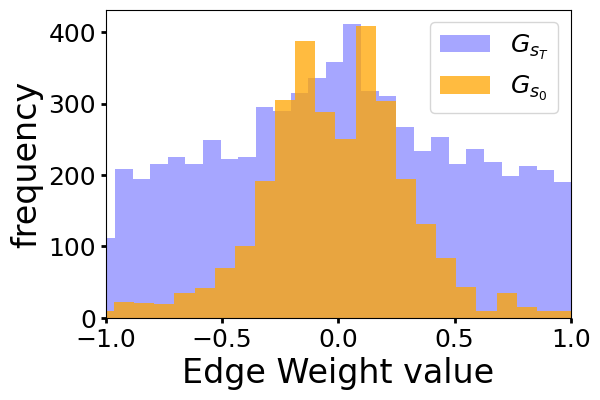

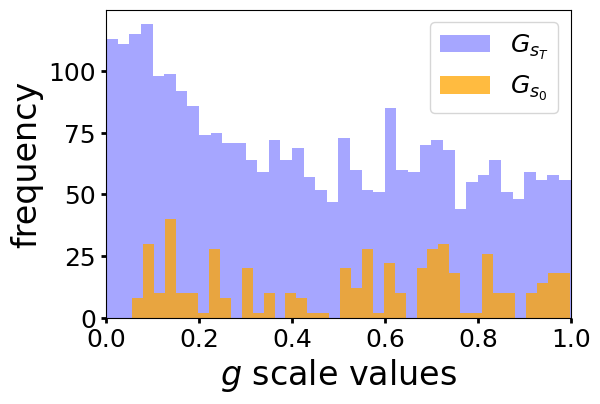

In [6]:
###plot final network edge weights distribution from first i=0 and last models i=9 in AllGraphs_list[modelrep][i]
###and get it for all model repetitions for final diverse prediction models as well

def NetStr_return(ModelRep, AllGraphs_list):
    G_inits = []; G_finals = []
    weights_init = []; weights_final = []
    for ModelRep in range(Model_Reps):
        G_init = AllGraphs_list[ModelRep][0]  ###first model
        G_final = AllGraphs_list[ModelRep][-1]  ###last model
        G_inits.extend(G_init.edges(data='weight'))
        G_finals = G_final.edges(data='weight')
        weights_init.append([w for _, _, w in G_inits])
        weights_final.append([w for _, _, w in G_finals])

    ###flatten the weights lists for all model repetitions
    weights_init = [w for sublist in weights_init for w in sublist]
    weights_final = [w for sublist in weights_final for w in sublist]
    
    return G_inits, G_finals, weights_init, weights_final

G_inits0, G_finals0, weights_init0, weights_final0 = NetStr_return(Model_Reps, AllGraphs_list0)
G_inits1, G_finals1, weights_init1, weights_final1 = NetStr_return(Model_Reps, AllGraphs_list1)
G_inits2, G_finals2, weights_init2, weights_final2 = NetStr_return(Model_Reps, AllGraphs_list2)

###join init and final weights for all model repetitions
weights_init = weights_init0 + weights_init1 + weights_init2
weights_final = weights_final0 + weights_final1 + weights_final2

####Rand Rep init and final data######################################
G_inits_R0, G_finals_R0, weights_init_R0, weights_final_R0 = NetStr_return(Model_Rand_Reps, AllGraphs_list_R0)
G_inits_R1, G_finals_R1, weights_init_R1, weights_final_R1 = NetStr_return(Model_Rand_Reps, AllGraphs_list_R1)

###join init and final weights for all model repetitions
weights_init_R = weights_init_R0 + weights_init_R1
weights_final_R = weights_final_R0 + weights_final_R1
#######################################################################

###put 2  different yaxis for the two histograms
fig, ax1 = plt.subplots(figsize=(6,4))
# ax2 = ax1.twinx()
ax1.hist(weights_final, bins=70, alpha=0.35, label='$G_{s_{T}}$', color='blue')
ax1.hist(weights_init, bins=70, alpha=0.75, zorder=1, color='orange', label='$G_{s_{0}}$')
###put ax1 ylabel in blue
ax1.set_xlabel('Network Edge Weights', fontsize=24)
# ax2.set_ylabel('', color='orange', fontsize=24)
ax1.set_ylabel('frequency', fontsize=24)
ax1.legend(loc='upper right', fontsize=18)
# ax2.legend(loc='upper right', fontsize=16)

ax1.tick_params(axis='both', which='major', labelsize=18, width=2, color='k', labelcolor='k')
# ax2.tick_params(axis='both', which='major', labelsize=18, width=2, color='orange', labelcolor='orange')
plt.xlabel('Edge Weight value', fontsize=24)
plt.xlim(-1.0, 1.0)
# plt.savefig(f"{DataDir}/edge_weights_distribution.svg")
plt.show()

###plot G_scale distribution from final model
##similarly, using all model reps
def g_scale_collect(FM_divPreds_g_scales):
    g_scale_f_all = []
    for g_scale_f in FM_divPreds_g_scales:
        g_scale_f_all.extend(g_scale_f)
    return g_scale_f_all

def g_scale_init_collect(All_g_scales_list):
     g_scale_all_inits = []
     for ModelRep in range(Model_Reps):
          g_scale_all_inits.extend(All_g_scales_list[ModelRep][0])
     return g_scale_all_inits

g_scale_all_inits0 = g_scale_init_collect(All_g_scales_list0)
g_scale_all_inits1 = g_scale_init_collect(All_g_scales_list1)
g_scale_all_inits2 = g_scale_init_collect(All_g_scales_list2)

####join g_scale_all_inits for all model repetitions
g_scale_all_inits = g_scale_all_inits0 + g_scale_all_inits1 + g_scale_all_inits2

g_scale_f_all0 = g_scale_collect(FM_divPreds_g_scales0)
g_scale_f_all1 = g_scale_collect(FM_divPreds_g_scales1)
g_scale_f_all2 = g_scale_collect(FM_divPreds_g_scales2)

###join g_scale_f_all for all model repetitions
g_scale_f_all = g_scale_f_all0 + g_scale_f_all1 + g_scale_f_all2


###also putting 2 different yaxis for the two histograms
fig, ax1 = plt.subplots(figsize=(6,4))
# ax2 = ax1.twinx()
####ax1 initial model

ax1.hist(g_scale_f_all, bins=40, alpha=0.35, color='blue', label='$G_{s_{T}}$')
ax1.hist(g_scale_all_inits, bins=40, alpha=0.75, zorder=1, color='orange', label='$G_{s_{0}}$')
ax1.set_xlabel('$g$ scale values', fontsize=24)
ax1.set_ylabel('frequency', fontsize=24)
# ax2.set_ylabel('', color='orange', fontsize=24)
ax1.legend(loc='upper right', fontsize=18)
# ax2.legend(loc='upper right', fontsize=14)
###put ax1 legend to just below the ax2 legend and bring it to front
# ax1.legend(bbox_to_anchor=(0.55, 0.82), loc='upper left', fontsize=14)
## bring ax1 legend to front
# ax1.legend_.set_zorder(1)
plt.xlim(0, 1.0)
ax1.tick_params(axis='both', which='major', labelsize=18, width=2, color='k', labelcolor='k')

# ax2.tick_params(axis='both', which='major', labelsize=18, width=2, color='orange', labelcolor='orange')
# plt.savefig(f"{DataDir}/g_scale_distribution.svg")
plt.show()

In [7]:
def Plot_ts(N_O, Inps, Outs, Outs_P, Trans, Tillt, Orig_Colrs, Pred_Colrs, Y_Labels, Model_Reps, save=False, save_dir=None, PlotName=''):
    # print('Output {}: MSE={:.10f}'.format(j, np.mean((Outs[j,Trans:Tillt+Trans] - Outs_t[j,:Tillt])**2)))
    for j in range(Outs.shape[0]):
        for i in range(N_O):
            fig_size = plt.rcParams["figure.figsize"]  
            fig_size[0] = 6; fig_size[1] = 2
            plt.rcParams["figure.figsize"] = fig_size  

            plt.plot(Inps[j, 0, Trans:Tillt+Trans]/20, lw=1.5, color='gray', label='Input')
            plt.plot(Outs[j, i,Trans:Tillt+Trans], lw=4, color=Orig_Colrs[i], label='Original')
            for rp in range(Model_Reps):
                ###put overhead bar and label for predicted lines
                plt.plot(Outs_P[rp, j, i], lw=2, ls='--', color=Pred_Colrs[i], label='Predicted {}$_{{p}}$'.format(Y_Labels[i]))
            plt.ylabel(Y_Labels[i], fontsize=24)
            plt.xlabel('time', fontsize=24)
            ###put text for the max amplitude of the input signal
            max_amp = np.max(Inps[j, 0, Trans:Tillt+Trans])
            ##position in top left corner
            plt.text(0.2, 0.35, f'$S_{{amp}}$={max_amp:.2f}', fontsize=18, color='k')
            ###removing duplicate labels in legend
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize=18)
            plt.xlim(0, 180)
            plt.ylim(-0.01, np.max(Outs[j,i])+0.05)
            ##make thick ticks
            plt.tick_params(axis='both', which='major', labelsize=18, width=2)
            if save and save_dir is not None:
                plt.savefig(f"{save_dir}/{PlotName}plot_{j}_{i}.svg")
            plt.show()

In [8]:
### definning Plot_t_ModRep so that it can be used for plotting predictions from all model repetitions
### using FM_divPreds_Predictions and FM_tst_Predictions which are lists of predictions for all model repetitions, to plot predictions for each model repetition
###using FM_divPreds_Predictions and FM_tst_Predictions which are lists of predictions for all model repetitions, to plot predictions for each model repetition

Orig_Colrs=['r','k']
Pred_Colrs=['b', 'green']
Y_Labels = ['$E$', '$I$']
Tillt = 200 

###join at axis 0 for all model repetitions
FM_tst_Predictions = np.concatenate((FM_tst_Predictions0, FM_tst_Predictions1, FM_tst_Predictions2), axis=0)
FM_divPreds_Predictions = np.concatenate((FM_divPreds_Predictions0, FM_divPreds_Predictions1, FM_divPreds_Predictions2), axis=0)

# Plot_ts(N_O, Inps_test_O, Outs_test_O, FM_tst_Predictions, Transs, Tillt, Orig_Colrs, Pred_Colrs, \
#         Y_Labels, Model_Reps, save=True, save_dir=DataDir, PlotName='TestPreds_')  
  
# Plot_ts(N_O, Inps_pred_Diverse_O, Outs_pred_Diverse_O, FM_divPreds_Predictions, Transs, Tillt,\
#          Orig_Colrs, Pred_Colrs, Y_Labels, Model_Reps, save=False, save_dir=DataDir, PlotName='DiversePreds_')

In [9]:
###get the max E and I values of the predictions for each model rep and input type from FM_divPreds_Predictions

def get_max_preds(Data, Model_Reps):
    Max_E_Preds = np.zeros((Model_Reps, Data.shape[1]))  ###shape is (Model_Reps, N_O, N_I, T)
    Max_I_Preds = np.zeros((Model_Reps, Data.shape[1]))  ###shape is (Model_Reps, N_O, N_I, T)
    for ModelRep in range(Model_Reps):
        for j in range(Data.shape[1]):  
            Max_E_Preds[ModelRep, j] = np.max(Data[ModelRep, j, 0, :])
            Max_I_Preds[ModelRep, j] = np.max(Data[ModelRep, j, 1, :])
    return Max_E_Preds, Max_I_Preds

def get_max_orig(Data, Inp, Model_Reps):
    ###Outs_pred_Diverse_O.shape is (18, 2, T)
    Max_E_Orig = np.zeros((Data.shape[0]))  ###shape is (N_O, N_I, T)
    Max_I_Orig = np.zeros((Data.shape[0]))  ###shape is (N_O, N_I, T)
    Max_inp = np.zeros((Data.shape[0]))  ###shape is (N_O, N_I, T)
    for j in range(Data.shape[0]):  
        Max_E_Orig[j] = np.max(Data[j, 0, :])
        Max_I_Orig[j] = np.max(Data[j, 1, :])
        Max_inp[j] = np.max(Inp[j, 0, :])
    return Max_E_Orig, Max_I_Orig, Max_inp


Max_E_Orig, Max_I_Orig, Max_inp = get_max_orig(Outs_pred_Diverse_O, Inps_pred_Diverse_O, Model_Reps)
Max_E_FM_DivPreds0, Max_I_FM_DivPreds0 = get_max_preds(FM_divPreds_Predictions0, Model_Reps)
Max_E_FM_DivPreds1, Max_I_FM_DivPreds1 = get_max_preds(FM_divPreds_Predictions1, Model_Reps)
Max_E_FM_DivPreds2, Max_I_FM_DivPreds2 = get_max_preds(FM_divPreds_Predictions2, Model_Reps)

print('Max E Predictions 15 shape:', Max_E_FM_DivPreds0.shape, 'Max I Predictions shape:', Max_I_FM_DivPreds0.shape)
print('Max E Predictions 25 shape:', Max_E_FM_DivPreds1.shape, 'Max I Predictions shape:', Max_I_FM_DivPreds1.shape)
print('Max E Predictions 35 shape:', Max_E_FM_DivPreds2.shape, 'Max I Predictions shape:', Max_I_FM_DivPreds2.shape)
print('Max E Original shape:', Max_E_Orig.shape, 'Max I Original shape:', Max_I_Orig.shape)
print('Max Input shape:', Max_inp.shape)

Max E Predictions 15 shape: (10, 18) Max I Predictions shape: (10, 18)
Max E Predictions 25 shape: (10, 18) Max I Predictions shape: (10, 18)
Max E Predictions 35 shape: (10, 18) Max I Predictions shape: (10, 18)
Max E Original shape: (18,) Max I Original shape: (18,)
Max Input shape: (18,)


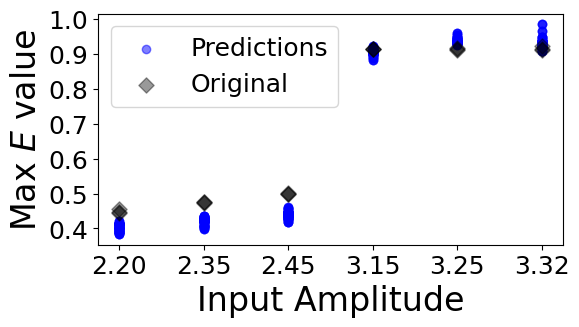

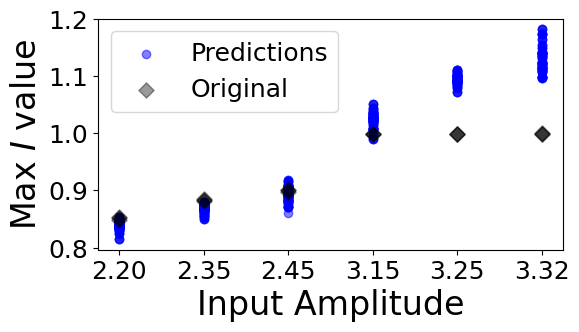

In [10]:
###make a scatter plot x axis is Max_inps, y axis is Max_E_Preds. Scatter is for each model repetitions 10

def Plot_Scatter_Preds(Max_inp, Max_Orig, Max_FM_DivPreds0, Max_FM_DivPreds1, Max_FM_DivPreds2, Ylabel, Model_Reps, save=False, save_dir=None): 
    plt.figure(figsize=(6,3))
    x_pred = np.tile(Max_inp, Model_Reps)  # repeat 18 inputs for each of 10 model reps -> 180 points
    # map input values to equally spaced x positions
    unique_inps = np.unique(Max_inp)
    x_pos = np.arange(len(unique_inps))
    x_map = {v: i for i, v in enumerate(unique_inps)}

    # redraw using equidistant x positions
    plt.cla()
    plt.scatter([x_map[v] for v in x_pred], Max_FM_DivPreds0.flatten(),
                color='blue', alpha=0.5, zorder=1, label='Predictions')
    plt.scatter([x_map[v] for v in x_pred], Max_FM_DivPreds1.flatten(),
                color='blue', alpha=0.5, zorder=1)
    plt.scatter([x_map[v] for v in x_pred], Max_FM_DivPreds2.flatten(),
                color='blue', alpha=0.5, zorder=1)
    plt.scatter([x_map[v] for v in Max_inp], Max_Orig.flatten(),
                color='k', alpha=0.4, s=60, marker='D', label='Original')

    # show original input values as tick labels
    plt.xticks(x_pos, [f"{v:.2f}" for v in unique_inps], fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Input Amplitude', fontsize=24)
    plt.ylabel('Max {} value'.format(Ylabel), fontsize=24)
    plt.legend(fontsize=18, loc='upper left')
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/Scatter_Max_{Ylabel}_Preds.svg")
    plt.show()

Plot_Scatter_Preds(Max_inp, Max_E_Orig, Max_E_FM_DivPreds0, Max_E_FM_DivPreds1, Max_E_FM_DivPreds2, '$E$', Model_Reps, save=False, save_dir=DataDir)
Plot_Scatter_Preds(Max_inp, Max_I_Orig, Max_I_FM_DivPreds0, Max_I_FM_DivPreds1, Max_I_FM_DivPreds2, '$I$', Model_Reps, save=False, save_dir=DataDir)


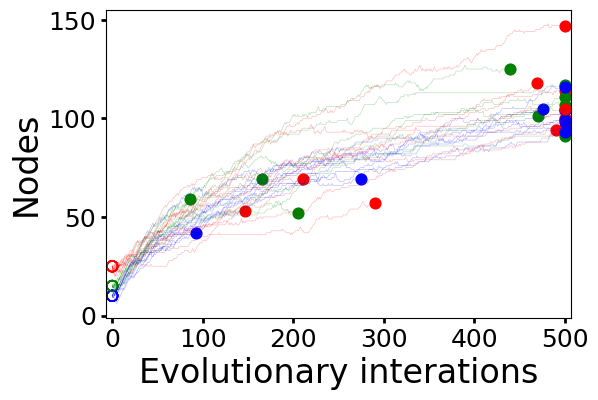

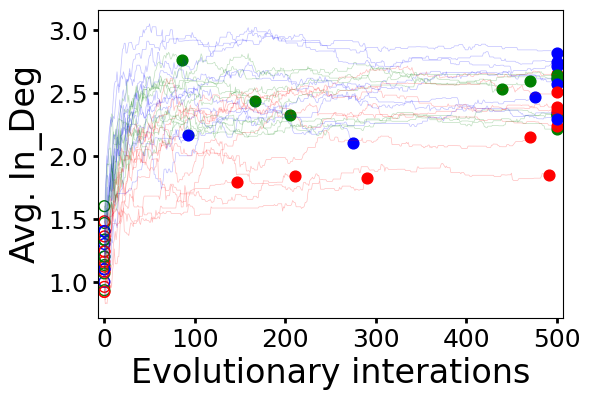

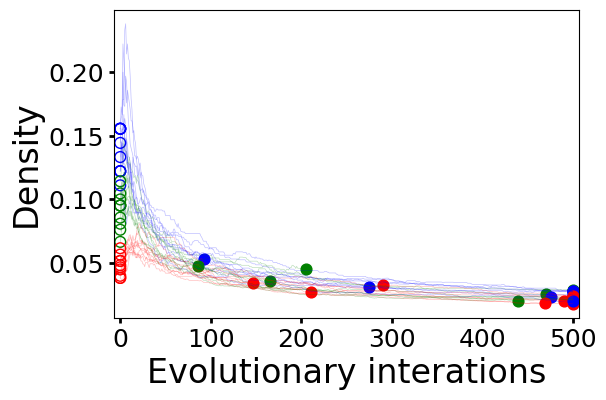

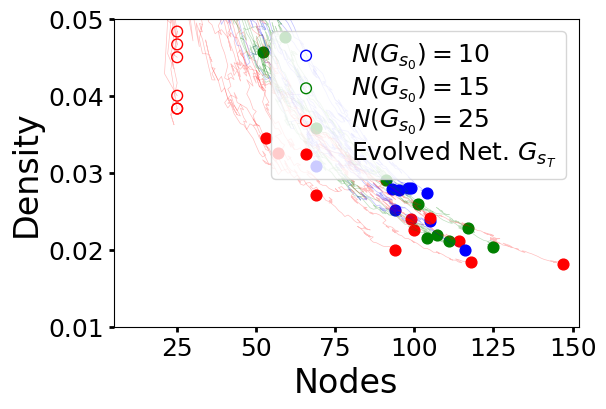

In [11]:
###plot number of nodes over the evolution for all model repetitions

def FirstZeroLocFinder(NetMsrs):
    ZerosLoc = np.where(NetMsrs==0)[0]
    if len(ZerosLoc)>=1:
        ZerosLocFirst=ZerosLoc[0]
    else:
        ZerosLocFirst=-1
    return ZerosLocFirst

def plot_net_measure(NetMsr_list0, NetMsr_list1, NetMsr_list2, measure_index, Model_Reps, MsrName, save=False, save_dir=None):
    FirstZeroLocs0 = []; FirstZeroLocs1 = []; FirstZeroLocs2 = []
    for rep in range(Model_Reps):
        FirstZeroLocs0.append(FirstZeroLocFinder(NetMsr_list0[rep][:,measure_index]))
        FirstZeroLocs1.append(FirstZeroLocFinder(NetMsr_list1[rep][:,measure_index]))
        FirstZeroLocs2.append(FirstZeroLocFinder(NetMsr_list2[rep][:,measure_index]))

    plt.figure(figsize=(6,4))
    for rep in range(Model_Reps):
        plt.plot(NetMsr_list0[rep][:FirstZeroLocs0[rep],measure_index], lw=0.5, alpha=0.25, color='blue')
        plt.plot(NetMsr_list1[rep][:FirstZeroLocs1[rep],measure_index], lw=0.5, alpha=0.25, color='green')
        plt.plot(NetMsr_list2[rep][:FirstZeroLocs2[rep],measure_index], lw=0.5, alpha=0.25, color='red')

        ###mark inital point with orange open circle
        ###filler marker with white color and edgecolor with respective color for each model repetition
        plt.scatter(0, NetMsr_list0[rep][0,measure_index], color='none', edgecolors='blue', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        
        plt.scatter(0, NetMsr_list1[rep][0,measure_index], color='none', edgecolors='green', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        plt.scatter(0, NetMsr_list2[rep][0,measure_index], color='none', edgecolors='red', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")

        ###scatter plot for the last point before zero
        if FirstZeroLocs0[rep]>0:
            plt.scatter(FirstZeroLocs0[rep]-1, NetMsr_list0[rep][FirstZeroLocs0[rep]-1,measure_index], color='blue', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        if FirstZeroLocs1[rep]>0:
            plt.scatter(FirstZeroLocs1[rep]-1, NetMsr_list1[rep][FirstZeroLocs1[rep]-1,measure_index], color='green', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        if FirstZeroLocs2[rep]>0:
            plt.scatter(FirstZeroLocs2[rep]-1, NetMsr_list2[rep][FirstZeroLocs2[rep]-1,measure_index], color='red', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")   
    plt.xlabel('Evolutionary interations', fontsize=24)
    plt.ylabel('{}'.format(MsrName), fontsize=24)
    ###ticks fontsize
    plt.tick_params(axis='both', which='major', labelsize=18, width=2)
    plt.xlim(-7, 507)
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/{MsrName}_evolution_plot.svg")
    # plt.xscale('log')
    plt.show()

###similarly making density vs nodes plot
def plot_density_vs_nodes(NetMsr_list0, NetMsr_list1, NetMsr_list2, Model_Reps, save=False, save_dir=None):
    plt.figure(figsize=(6,4))
    for rep in range(Model_Reps):
        Nodes0 = NetMsr_list0[rep][:,0];  Density0 = NetMsr_list0[rep][:,5]
        Nodes1 = NetMsr_list1[rep][:,0];  Density1 = NetMsr_list1[rep][:,5]
        Nodes2 = NetMsr_list2[rep][:,0];  Density2 = NetMsr_list2[rep][:,5]

        ###stop the plot at the first zero of nodes
        FirstZeroLoc0 = FirstZeroLocFinder(Nodes0)
        FirstZeroLoc1 = FirstZeroLocFinder(Nodes1)
        FirstZeroLoc2 = FirstZeroLocFinder(Nodes2)

        plt.plot(Nodes0[:FirstZeroLoc0], Density0[:FirstZeroLoc0], lw=0.5, alpha=0.25, color='blue')
        plt.plot(Nodes1[:FirstZeroLoc1], Density1[:FirstZeroLoc1], lw=0.5, alpha=0.25, color='green')
        plt.plot(Nodes2[:FirstZeroLoc2], Density2[:FirstZeroLoc2], lw=0.5, alpha=0.25, color='red')

        ###mark inital point with orange open circle
        plt.scatter(NetMsr_list0[rep][0,0], NetMsr_list0[rep][0,5], color='none', edgecolors='blue', \
                        s=60, label='$N(G_{s_{0}})=10$')
        plt.scatter(NetMsr_list1[rep][0,0], NetMsr_list1[rep][0,5], color='none', edgecolors='green', \
                        s=60, label='$N(G_{s_{0}})=15$')
        plt.scatter(NetMsr_list2[rep][0,0], NetMsr_list2[rep][0,5], color='none', edgecolors='red', \
                        s=60, label='$N(G_{s_{0}})=25$')

        ###scatter plot for the last point before zero
        if FirstZeroLoc0>0:
            plt.scatter(NetMsr_list0[rep][FirstZeroLoc0-1,0], NetMsr_list0[rep][FirstZeroLoc0-1,5], color='blue', \
                        s=60, label='Evolved Net. $G_{s_{T}}$')
        if FirstZeroLoc1>0:
            plt.scatter(NetMsr_list1[rep][FirstZeroLoc1-1,0], NetMsr_list1[rep][FirstZeroLoc1-1,5], color='green', \
                        s=60, label='Evolved Net. $G_{s_{T}}$')
        if FirstZeroLoc2>0:
            plt.scatter(NetMsr_list2[rep][FirstZeroLoc2-1,0], NetMsr_list2[rep][FirstZeroLoc2-1,5], color='red', \
                        s=60, label='Evolved Net. $G_{s_{T}}$')

    plt.xlabel('Nodes', fontsize=24)
    plt.ylabel('Density', fontsize=24)
    ###ticks fontsize
    plt.tick_params(axis='both', which='major', labelsize=18, width=2)
    
    ###removing duplicate labels in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))    
    #reduce spacing between legend entries 
    plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=18, labelspacing=0.1)

    plt.xlim(5, 152) 
    plt.ylim(0.01, 0.05)
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/Density_vs_Nodes_plot.svg")
    # plt.xscale('log')
    plt.show()  

Mrs_Names = ['Nodes', 'Avg. CC', 'Avg. In_Deg', 'Avg. Out_Deg', 'Communities', 'Density']

plot_net_measure(NetMsr_list0, NetMsr_list1, NetMsr_list2, 0, Model_Reps, Mrs_Names[0], save=False, save_dir=DataDir) 
# plot_net_measure(NetMsr_list, 1, Model_Reps, Mrs_Names[1])
plot_net_measure(NetMsr_list0, NetMsr_list1, NetMsr_list2, 2, Model_Reps, Mrs_Names[2], save=False, save_dir=DataDir)
# plot_net_measure(NetMsr_list, 3, Model_Reps, Mrs_Names[3])
# plot_net_measure(NetMsr_list, 4, Model_Reps, Mrs_Names[4])
plot_net_measure(NetMsr_list0, NetMsr_list1, NetMsr_list2, 5, Model_Reps, Mrs_Names[5], save=False, save_dir=DataDir)

plot_density_vs_nodes(NetMsr_list0, NetMsr_list1, NetMsr_list2, Model_Reps, save=False, save_dir=DataDir)

C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\3224240486.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Initial Network', y='Final Nodes', data=Nodes_df, palette=Colors, scale="width", \
C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\3224240486.py:17: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Initial Network', y='Final Nodes', data=Nodes_df, palette=Colors, scale="width", \
C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\3224240486.py:17: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.5`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x='Initial Network', y='Final

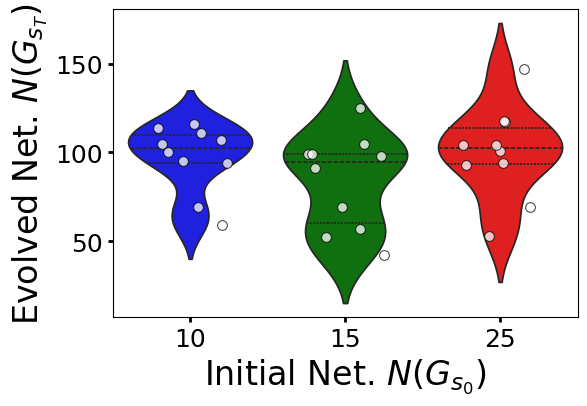

In [12]:
###making violin plots for the final nodes and comparing across inital networks = [10, 15, 25]

###making a dataframe for the final nodes for each model repetition and initial network
import pandas as pd
Nodes_df = pd.DataFrame({'Model Rep': np.arange(Model_Reps).repeat(3), 'Initial Network': np.tile([10, 15, 25], Model_Reps), \
                         'Final Nodes': FM_tst_NetMsr0 + FM_tst_NetMsr1 + FM_tst_NetMsr2})


###making sns violin plot for final nodes and comparing across initial networks = [10, 15, 25]
import seaborn as sns

##set blue, green, red color palette for the three initial networks
Colors = ['blue', 'green', 'red']

def plot_violin_final_nodes(Nodes_df, save=False, save_dir=None):
    plt.figure(figsize=(6,4))
    sns.violinplot(x='Initial Network', y='Final Nodes', data=Nodes_df, palette=Colors, scale="width", \
               inner="quartiles", bw=0.5)
    sns.stripplot(x='Initial Network', y='Final Nodes', data=Nodes_df, color='white', edgecolor='k', \
                  s=7, linewidth=0.75, jitter=0.25, alpha=0.75)
    plt.xticks(fontsize=18)
    plt.xlabel('Initial Net. $N(G_{s_{0}})$', fontsize=24)
    plt.ylabel('Evolved Net. $N(G_{s_{T}})$', fontsize=24)
    plt.tick_params(axis='both', which='major', labelsize=18, width=2)
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/Violin_Final_Nodes.svg")
    plt.show()

plot_violin_final_nodes(Nodes_df, save=False, save_dir=DataDir)


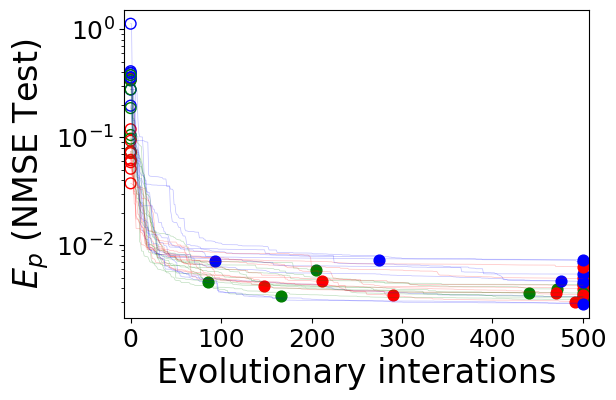

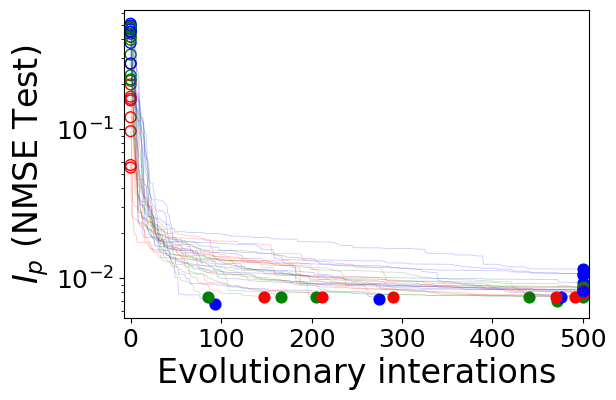

In [13]:
###similarly plotting errors from Scores_list for all model repetitions over evolutionary iterations
###Scores_list has shappe [modelreps(10), traintest(2), evolutionary iterations(210), mean of mse and sd of E (2), mean of mse and sd of I (2)]

def plot_errors(Scores_list0, Scores_list1, Scores_list2, Model_Reps, EorI, save=False, save_dir=None):
    EorI_name = '$E_{p}$' if EorI==0 else '$I_{p}$'
    plt.figure(figsize=(6,4))
    for rep in range(Model_Reps):
        Train_Err0 = Scores_list0[rep][0,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)
        Test_Err0 = Scores_list0[rep][1,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)

        Train_Err1 = Scores_list1[rep][0,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)
        Test_Err1 = Scores_list1[rep][1,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)

        Train_Err2 = Scores_list2[rep][0,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)
        Test_Err2 = Scores_list2[rep][1,:,0,EorI]  ###shape is (evolutionary iterations(210), mean and sd of E and I)

        ###stop the plot at the first zero of nodes
        FirstZeroLoc0 = FirstZeroLocFinder(NetMsr_list0[rep][:,0])
        FirstZeroLoc1 = FirstZeroLocFinder(NetMsr_list1[rep][:,0])
        FirstZeroLoc2 = FirstZeroLocFinder(NetMsr_list2[rep][:,0])

        plt.plot(Test_Err0[:FirstZeroLoc0], lw=0.5, alpha=0.25, color='blue')
        plt.plot(Test_Err1[:FirstZeroLoc1], lw=0.5, alpha=0.25, color='green')
        plt.plot(Test_Err2[:FirstZeroLoc2], lw=0.5, alpha=0.25, color='red')

        ###mark inital point with orange open circle
        plt.scatter(0, Test_Err0[0], color='none', edgecolors='blue', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        plt.scatter(0, Test_Err1[0], color='none', edgecolors='green', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        plt.scatter(0, Test_Err2[0], color='none', edgecolors='red', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")
        ###scatter plot for the last point before zero
        if FirstZeroLoc0>0:
            plt.scatter(FirstZeroLoc0-1, Test_Err0[FirstZeroLoc0-1], color='blue', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")   
        if FirstZeroLoc1>0:
            plt.scatter(FirstZeroLoc1-1, Test_Err1[FirstZeroLoc1-1], color='green', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")   
        if FirstZeroLoc2>0:
            plt.scatter(FirstZeroLoc2-1, Test_Err2[FirstZeroLoc2-1], color='red', \
                        s=60, label='Model Rep {}'.format(rep) if rep==0 else "")   

    plt.xlabel('Evolutionary interations', fontsize=24)
    plt.ylabel(f'{EorI_name} (NMSE Test)', fontsize=24)
    ###ticks fontsize
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlim(-7, 507)
    ###make y axis log scale
    plt.yscale('log')
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/Test_NMSE_evolution_plot_{EorI_name}.svg")
    plt.show()

plot_errors(Scores_list0, Scores_list1, Scores_list2, Model_Reps, EorI=0, save=False, save_dir=DataDir)
plot_errors(Scores_list0, Scores_list1, Scores_list2, Model_Reps, EorI=1, save=False, save_dir=DataDir)


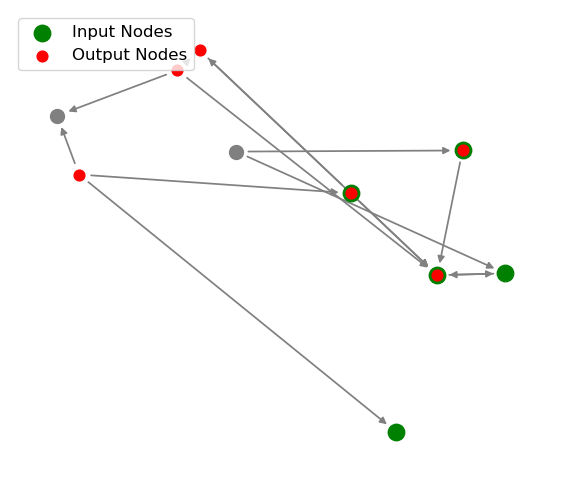

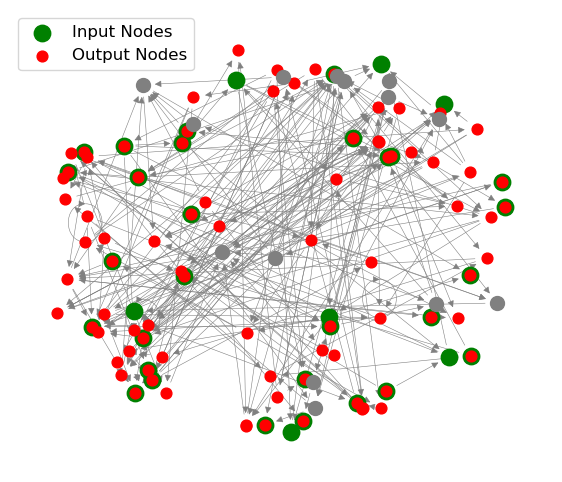

In [14]:
def NetStr_return(ModelRep, InitorFinal, AllGraphs_list, AllInpsNodes_list, AllOutsNodes_list):
    if InitorFinal=='Initial':
         i=0
         EdgeWidth=1.25
    elif InitorFinal=='Final':
        i=-1
        EdgeWidth=0.4
    G_init = AllGraphs_list[ModelRep][i]
    InpsNodes_init = AllInpsNodes_list[ModelRep][i] 
    OutsNodes_init = AllOutsNodes_list[ModelRep][i]
    # flatten nested node lists to avoid "TypeError: unhashable type: 'list'"
    InpsNodes_init_flat = [int(n) for n in InpsNodes_init[0]] if len(InpsNodes_init) == 1 else [int(n) for n in InpsNodes_init]

    OutsNodes_init_flat = []
    for group in OutsNodes_init:
        if isinstance(group, (list, np.ndarray)):
            OutsNodes_init_flat.extend([int(n) for n in group])
        else:
            OutsNodes_init_flat.append(int(group))
    OutsNodes_init_flat = sorted(set(OutsNodes_init_flat))
    return G_init, InpsNodes_init_flat, OutsNodes_init_flat, EdgeWidth

def plot_network(G, InpsNodes, OutsNodes, EdgeWidth, save=False, save_dir=None, PlotName=''):
    fig, ax = plt.subplots(figsize=(7, 6))
    pos = nx.spring_layout(G, seed=42)

    weights = np.array([G[u][v].get('weight', 0.0) for u, v in G.edges()], dtype=float)
    if weights.size == 0:
        weights = np.array([0.0])

    wmin, wmax = weights.min(), weights.max()
    norm_weights = np.zeros_like(weights) if np.isclose(wmin, wmax) else (weights - wmin) / (wmax - wmin)
    edge_colors = plt.cm.viridis(norm_weights)

    nx.draw_networkx_edges(G, pos, edge_color='gray', width=EdgeWidth, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=InpsNodes, node_color='green', node_size=140, label='Input Nodes', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=OutsNodes, node_color='red', node_size=60, label='Output Nodes', ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes() if n not in InpsNodes and n not in OutsNodes],
        node_color='gray', alpha=1, node_size=100, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=wmin, vmax=wmax))
    sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax, label='Edge Weight', fraction=0.02, pad=0.01)
    # cbar.ax.tick_params(length=3, width=0.2, labelsize= 11)

    ax.legend(fontsize=12, loc='upper left')
    ax.set_axis_off()
    if save and save_dir is not None:
        fig.savefig(f"{save_dir}/{PlotName}.svg")
    plt.show()


###plotting initial and final network for model repetition 0
ModelRep = 6 #6

G_init, InpsNodes_init_flat, OutsNodes_init_flat, EdgeWidth_init = NetStr_return(ModelRep, 'Initial', AllGraphs_list0,\
                                                                     AllInpsNodes_list0, AllOutsNodes_list0)
plot_network(G_init, InpsNodes_init_flat, OutsNodes_init_flat, EdgeWidth_init,\
                save=False, save_dir=DataDir, PlotName='Initial_Network')

G_final, InpsNodes_final_flat, OutsNodes_final_flat, EdgeWidth_final = NetStr_return(ModelRep, 'Final', AllGraphs_list0,\
                                                                     AllInpsNodes_list0, AllOutsNodes_list0)
plot_network(G_final, InpsNodes_final_flat, OutsNodes_final_flat, EdgeWidth_final, save=False,\
    save_dir=DataDir, PlotName='Final_Network')

## Node specificity analysis

### 1. of Evolved RC

FM_tst_W_outs list length: 30 FM_tst_Graphs list length: 30 FM_tst_InpsNodes list length: 30 FM_tst_OutsNodes list length: 30
Rep  0 | N= 95 | E= 25 I= 23 Shared=25 Periph= 22
Rep  1 | N= 98 | E= 13 I= 24 Shared=13 Periph= 48
Rep  2 | N= 94 | E= 20 I= 18 Shared=17 Periph= 39
Rep  3 | N= 69 | E= 11 I= 28 Shared=11 Periph= 19
Rep  4 | N= 42 | E= 10 I=  9 Shared= 9 Periph= 14
Rep  5 | N=104 | E= 12 I= 27 Shared=14 Periph= 51
Rep  6 | N=105 | E= 17 I= 30 Shared=23 Periph= 35
Rep  7 | N= 99 | E= 12 I= 29 Shared= 9 Periph= 49
Rep  8 | N= 93 | E= 19 I= 24 Shared=20 Periph= 30
Rep  9 | N=116 | E= 25 I= 28 Shared=27 Periph= 36
Rep 10 | N= 52 | E=  8 I= 13 Shared=10 Periph= 21
Rep 11 | N=101 | E= 19 I= 25 Shared=21 Periph= 36
Rep 12 | N=107 | E= 26 I= 22 Shared=28 Periph= 31
Rep 13 | N= 91 | E= 11 I= 30 Shared=12 Periph= 38
Rep 14 | N=104 | E= 25 I= 29 Shared=29 Periph= 21
Rep 15 | N=111 | E= 26 I= 32 Shared=20 Periph= 33
Rep 16 | N=125 | E= 24 I= 41 Shared=20 Periph= 40
Rep 17 | N=117 | E= 29 I

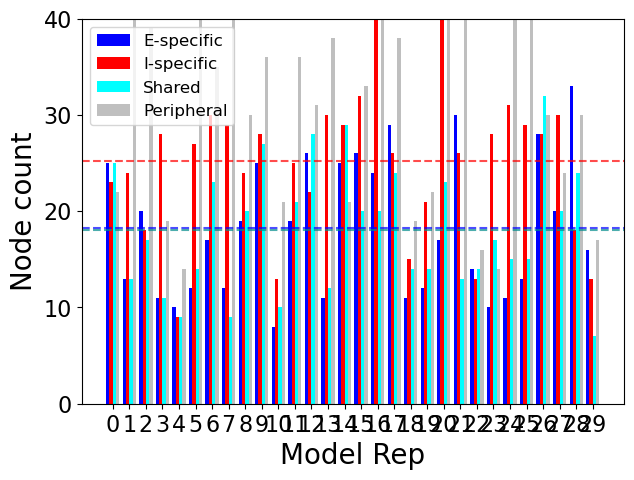

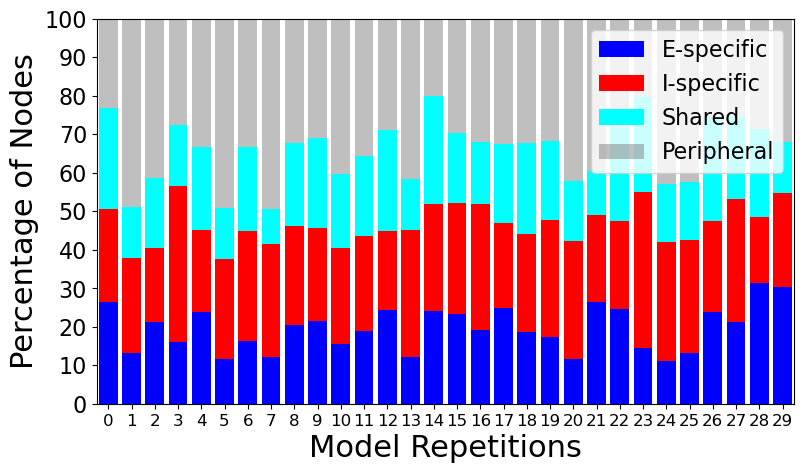

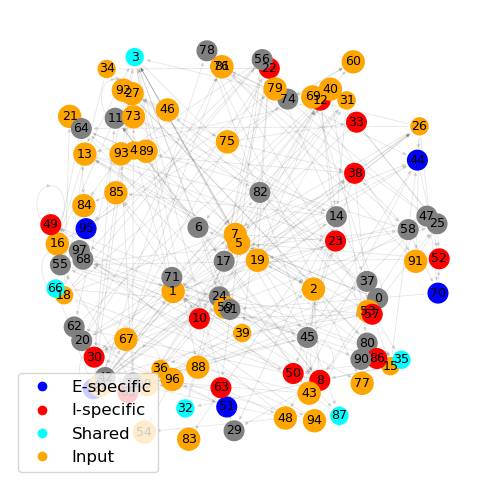

In [233]:
def _flatten_int_nodes(nodes):
    if isinstance(nodes, np.ndarray):
        nodes = nodes.tolist()
    if isinstance(nodes, (list, tuple, set)):
        flat = []
        for item in nodes:
            flat.extend(_flatten_int_nodes(item))
        return flat
    return [int(nodes)]

def node_specificity_analysis_allreps_v2(W_outs_all, Graphs_all, InpsNodes_all, OutsNodes_all,
                                          weight_thresh=0.05, best_rep=6, save=False, save_dir=None, RandNet=False, InitNet=False):
    """
    Handles variable-size networks across reps by computing per-rep statistics
    and aggregating at the population level rather than node level.
    """
    n_reps = len(W_outs_all)
    
    # ── Per-rep statistics (aggregated, not per-node) ─────────────────────────
    rep_stats = []
    
    for rp in range(n_reps):
        G   = Graphs_all[rp]
        N   = G.number_of_nodes()
        node_list   = list(G.nodes())
        node_to_idx = {n: i for i, n in enumerate(node_list)}

        out_E = set(_flatten_int_nodes(OutsNodes_all[rp][0]))
        out_I = set(_flatten_int_nodes(OutsNodes_all[rp][1]))

        # Build normalized contribution scores
        contrib = np.zeros((2, N))
        for i, (w, group) in enumerate(zip(W_outs_all[rp], 
                                           [OutsNodes_all[rp][0], OutsNodes_all[rp][1]])):
            w = np.asarray(w).ravel()
            group_flat = _flatten_int_nodes(group)
            for k, node in enumerate(group_flat):
                if k < len(w) and node in node_to_idx:
                    contrib[i, node_to_idx[node]] = abs(w[k])
        for i in range(2):
            mx = contrib[i].max()
            if mx > 0: contrib[i] /= mx

        score_E = contrib[0]
        score_I = contrib[1]

        # Classify nodes
        in_E = np.array([n in out_E and score_E[node_to_idx[n]] > weight_thresh
                         for n in node_list])
        in_I = np.array([n in out_I and score_I[node_to_idx[n]] > weight_thresh
                         for n in node_list])

        E_spec = np.where( in_E & ~in_I)[0]
        I_spec = np.where(~in_E &  in_I)[0]
        shared = np.where( in_E &  in_I)[0]
        periph = np.where(~in_E & ~in_I)[0]

        # Store per-rep summary statistics
        rep_stats.append({
            'rep'        : rp,
            'N_nodes'    : N,
            'N_edges'    : G.number_of_edges(),
            'n_E'        : len(E_spec),
            'n_I'        : len(I_spec),
            'n_shared'   : len(shared),
            'n_periph'   : len(periph),
            'pct_E'      : 100 * len(E_spec) / N,
            'pct_I'      : 100 * len(I_spec) / N,
            'pct_shared' : 100 * len(shared) / N,
            'pct_periph' : 100 * len(periph) / N,
            # Mean scores within each population
            'mean_scoreE_Enodes' : np.mean(score_E[E_spec]) if len(E_spec) > 0 else 0,
            'mean_scoreI_Inodes' : np.mean(score_I[I_spec]) if len(I_spec) > 0 else 0,
            'mean_scoreE_shared' : np.mean(score_E[shared]) if len(shared) > 0 else 0,
            'mean_scoreI_shared' : np.mean(score_I[shared]) if len(shared) > 0 else 0,
            # Store for per-rep structural analysis
            'score_E'    : score_E,
            'score_I'    : score_I,
            'E_spec_idx' : E_spec,
            'I_spec_idx' : I_spec,
            'shared_idx' : shared,
            'node_list'  : node_list,
            'G'          : G,
        })

        print(f"Rep {rp:2d} | N={N:3d} | "
              f"E={len(E_spec):3d} I={len(I_spec):3d} "
              f"Shared={len(shared):2d} Periph={len(periph):3d}")

    # ── Aggregate statistics across reps ──────────────────────────────────────
    keys = ['N_nodes', 'N_edges', 'n_E', 'n_I', 'n_shared', 'n_periph',
            'pct_E', 'pct_I', 'pct_shared', 'mean_scoreE_Enodes', 
            'mean_scoreI_Inodes', 'mean_scoreE_shared', 'mean_scoreI_shared']
    
    print("\n" + "="*60)
    print(f"  SUMMARY ACROSS {n_reps} REPS (mean ± std)")
    print("="*60)
    agg = {}
    for k in keys:
        vals = np.array([r[k] for r in rep_stats])
        agg[k] = {'mean': np.mean(vals), 'std': np.std(vals), 'all': vals}
        print(f"  {k:<30}: {np.mean(vals):7.2f} ± {np.std(vals):.2f}")

    # ── Plot 1: Per-rep node counts ───────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))

    # ax = axes[0]
    reps  = np.arange(n_reps)
    width = 0.2
    ax.bar(reps - 1.5*width, agg['n_E']['all'],      width, label='E-specific',  color='blue')
    ax.bar(reps - 0.5*width, agg['n_I']['all'],      width, label='I-specific',  color='red')
    ax.bar(reps + 0.5*width, agg['n_shared']['all'], width, label='Shared',      color='cyan')
    ax.bar(reps + 1.5*width, agg['n_periph']['all'], width, label='Peripheral',  color='gray',  alpha=0.5)
    # Mean lines
    ax.axhline(agg['n_E']['mean'],      color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(agg['n_I']['mean'],      color='red',    linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(agg['n_shared']['mean'], color='darkcyan',  linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('Model Rep', fontsize=20)
    ax.set_ylabel('Node count', fontsize=20)
    # ax.set_title('Node Classification per Rep\n(dashed = mean)')
    ax.set_xticks(reps)
    ###increase of x and y ticks
    ax.set_yticks(np.arange(0, max(agg['N_nodes']['all'])+5, 10))
    ax.set_xticklabels(reps, fontsize=16)
    ax.set_yticklabels(np.arange(0, max(agg['N_nodes']['all'])+5, 10), fontsize=16)
    ax.set_ylim(0, 40)
    # ax.set_yticks(fontsize=16)
    ax.legend(fontsize=12)
    if save and save_dir is not None:
        if RandNet==True:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis1_RandNet.svg")
        else:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis1.svg")
    plt.show()
    plt.show()

    # ── Plot 2: % composition per rep (stacked) ───────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(9, 5))
    # ax = axes[0]
    pct_E  = agg['pct_E']['all']
    pct_I  = agg['pct_I']['all']
    pct_S  = agg['pct_shared']['all']
    pct_P  = 100 - pct_E - pct_I - pct_S

    ax.bar(reps, pct_E, label='E-specific',  color='blue')
    ax.bar(reps, pct_I, bottom=pct_E, label='I-specific',  color='red')
    ax.bar(reps, pct_S, bottom=pct_E+pct_I, label='Shared', color='cyan')
    ax.bar(reps, pct_P, bottom=pct_E+pct_I+pct_S, label='Peripheral',  color='gray',  alpha=0.5)
    ax.set_xlabel('Model Repetitions', fontsize=22)
    ax.set_xticks(reps)
    ax.set_xticklabels(reps, fontsize=12)
    ax.set_yticks(np.arange(0, 101, 10))
    ax.set_yticklabels(np.arange(0, 101, 10), fontsize=16)
    ax.legend(loc='upper right', fontsize=16)
    ax.set_ylabel('Percentage of Nodes', fontsize=22)
    ax.set_xlim(-0.5,29.5)
    ax.set_ylim(0,100)
    if save and save_dir is not None:
        if RandNet==True:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis2_RandNet.svg")
        if InitNet==True:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis2_Init.svg")
        else:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis2.svg")
    plt.show()

    # ── Plot 3: Representative network (best_rep) ─────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    # ax   = axes[0]
    rs   = rep_stats[best_rep]
    G_rep = rs['G']
    colors_rep = ['gray'] * rs['N_nodes']
    for i in rs['E_spec_idx']: colors_rep[i] = 'blue'
    for i in rs['I_spec_idx']: colors_rep[i] = 'red'
    for i in rs['shared_idx']: colors_rep[i] = 'cyan'
    inp_set = set(_flatten_int_nodes(InpsNodes_all[best_rep]))
    nti = {n: i for i, n in enumerate(rs['node_list'])}
    for n in inp_set:
        if n in nti: colors_rep[nti[n]] = 'orange'

    node_sizes = [150 if i in rs['shared_idx'] else
                  250 if rs['node_list'][i] in inp_set else
                  200  for i in range(rs['N_nodes'])]

    pos = nx.spring_layout(G_rep, seed=42)
    nx.draw_networkx_nodes(G_rep, pos, node_color=colors_rep,
                           node_size=node_sizes, ax=ax)
    nx.draw_networkx_edges(G_rep, pos, alpha=0.1, arrows=True,
                           arrowsize=5, width=0.6, ax=ax)
    nx.draw_networkx_labels(G_rep, pos, font_size=9, ax=ax)

    ax.axis('off')

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor='blue', label='E-specific', markersize=8),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='red',    label='I-specific', markersize=8),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='cyan',      label='Shared',     markersize=8),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='orange',    label='Input',      markersize=8),
    ], fontsize=12, loc='lower left')

    plt.tight_layout()

    if save and save_dir is not None:
        if RandNet==True:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis3_RandNet.svg")
        else:
            plt.savefig(f"{save_dir}/Node_Specificity_Analysis3.svg")
    plt.show()

    return rep_stats, agg


#####join FM_tst_W_outs0, FM_tst_W_outs1, FM_tst_W_outs2 into a list FM_tst_W_outs at index 0,1,2 respectively. Similarly for FM_tst_Graphs, FM_tst_InpsNodes, FM_tst_OutsNodes
FM_tst_W_outs = FM_tst_W_outs0 + FM_tst_W_outs1 + FM_tst_W_outs2
FM_tst_Graphs = FM_tst_Graphs0 + FM_tst_Graphs1 + FM_tst_Graphs2
FM_tst_InpsNodes = FM_tst_InpsNodes0 + FM_tst_InpsNodes1 + FM_tst_InpsNodes2
FM_tst_OutsNodes = FM_tst_OutsNodes0 + FM_tst_OutsNodes1 + FM_tst_OutsNodes2

print('FM_tst_W_outs list length:', len(FM_tst_W_outs), 'FM_tst_Graphs list length:', len(FM_tst_Graphs), \
    'FM_tst_InpsNodes list length:', len(FM_tst_InpsNodes), 'FM_tst_OutsNodes list length:', len(FM_tst_OutsNodes))

rep_stats, agg = node_specificity_analysis_allreps_v2(FM_tst_W_outs,
    FM_tst_Graphs,
    FM_tst_InpsNodes,
    FM_tst_OutsNodes,
    weight_thresh=0.03,
    best_rep=1, save=True, save_dir=DataDir)

### 2. of ER Rand Nets

30 2 30
30 2 56
Rand W_outs list length: 30 Rand Graphs list length: 30 Rand InpsNodes list length: 30 Rand OutsNodes list length: 30
Rep  0 | N= 60 | E= 14 I=  8 Shared= 4 Periph= 34
Rep  1 | N= 60 | E= 13 I=  8 Shared= 9 Periph= 30
Rep  2 | N= 60 | E= 15 I=  9 Shared= 6 Periph= 30
Rep  3 | N= 60 | E=  8 I= 14 Shared=11 Periph= 27
Rep  4 | N= 60 | E= 12 I= 13 Shared=10 Periph= 25
Rep  5 | N= 60 | E=  9 I= 13 Shared=12 Periph= 26
Rep  6 | N= 60 | E=  9 I=  9 Shared=10 Periph= 32
Rep  7 | N= 60 | E= 16 I= 18 Shared= 8 Periph= 18
Rep  8 | N= 60 | E= 11 I= 14 Shared=12 Periph= 23
Rep  9 | N= 60 | E= 16 I= 16 Shared= 6 Periph= 22
Rep 10 | N= 60 | E= 14 I= 15 Shared= 9 Periph= 22
Rep 11 | N= 60 | E=  6 I= 13 Shared=10 Periph= 31
Rep 12 | N= 60 | E= 14 I= 12 Shared=13 Periph= 21
Rep 13 | N= 60 | E= 13 I= 12 Shared=12 Periph= 23
Rep 14 | N= 60 | E= 16 I= 13 Shared=10 Periph= 21
Rep 15 | N=100 | E= 24 I= 28 Shared=11 Periph= 37
Rep 16 | N=100 | E= 18 I= 23 Shared=15 Periph= 44
Rep 17 | N=100 |

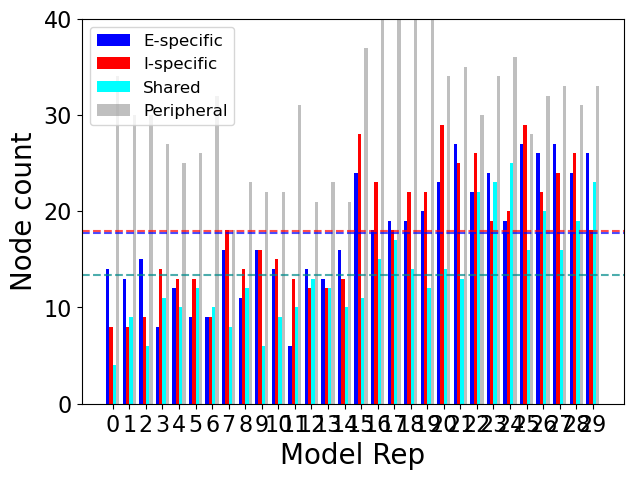

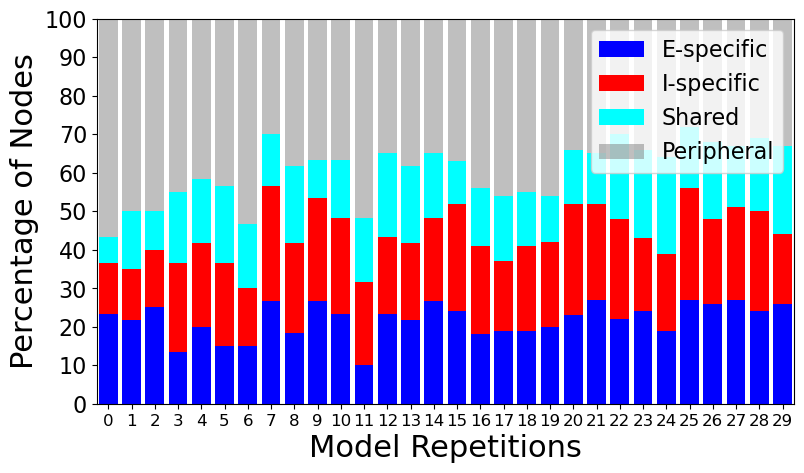

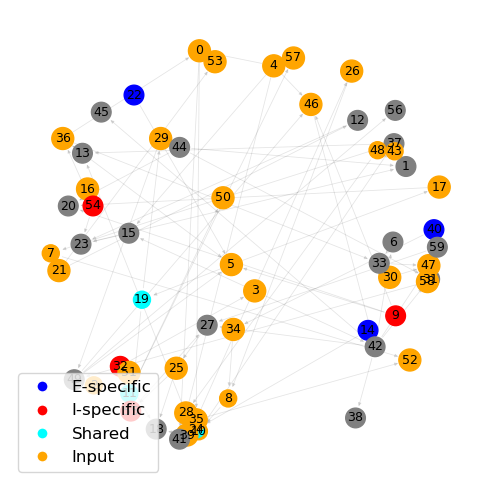

In [234]:
###Node classification for random networks######################################
####first joining the rand init 60 and 100
####and matching the strucutre of the inital network data to match that of final
####for the analyis above
All_W_outs_R = All_W_outs_R0 + All_W_outs_R1 
All_W_outs_R = [w[0] for w in All_W_outs_R]
All_W_outs_R = [w[0] for w in All_W_outs_R]


print(len(All_W_outs_R), len(All_W_outs_R[0]), len(All_W_outs_R[0][0]))
print(len(FM_tst_W_outs), len(FM_tst_W_outs[0]), len(FM_tst_W_outs[0][0]))

AllGraphs_list_R = AllGraphs_list_R0 + AllGraphs_list_R1
AllGraphs_list_R = [g[0] for g in AllGraphs_list_R]


AllInpsNodes_list_R = AllInpsNodes_list_R0 + AllInpsNodes_list_R1
AllInpsNodes_list_R = [i[0] for i in AllInpsNodes_list_R]

AllOutsNodes_list_R = AllOutsNodes_list_R0 + AllOutsNodes_list_R1 
AllOutsNodes_list_R = [o[0] for o in AllOutsNodes_list_R]


print('Rand W_outs list length:', len(All_W_outs_R), 'Rand Graphs list length:', len(AllGraphs_list_R), \
    'Rand InpsNodes list length:', len(AllInpsNodes_list_R), 'Rand OutsNodes list length:', len(AllOutsNodes_list_R))

Rand_rep_stats, Rand_agg = node_specificity_analysis_allreps_v2(All_W_outs_R,
    AllGraphs_list_R,
    AllInpsNodes_list_R,
    AllOutsNodes_list_R,
    weight_thresh=0.03,
    best_rep=1, save=False, save_dir=DataDir, RandNet=True)

### 3. of Inital Rand Nets

Rep  0 | N= 10 | E=  2 I=  2 Shared= 2 Periph=  4
Rep  1 | N= 10 | E=  3 I=  1 Shared= 0 Periph=  6
Rep  2 | N= 10 | E=  2 I=  2 Shared= 2 Periph=  4
Rep  3 | N= 10 | E=  2 I=  4 Shared= 1 Periph=  3
Rep  4 | N= 10 | E=  4 I=  4 Shared= 0 Periph=  2
Rep  5 | N= 10 | E=  3 I=  3 Shared= 2 Periph=  2
Rep  6 | N= 10 | E=  2 I=  3 Shared= 1 Periph=  4
Rep  7 | N= 10 | E=  3 I=  1 Shared= 1 Periph=  5
Rep  8 | N= 10 | E=  0 I=  0 Shared= 2 Periph=  8
Rep  9 | N= 10 | E=  3 I=  2 Shared= 1 Periph=  4
Rep 10 | N= 15 | E=  1 I=  2 Shared= 3 Periph=  9
Rep 11 | N= 15 | E=  1 I=  2 Shared= 1 Periph= 11
Rep 12 | N= 15 | E=  5 I=  3 Shared= 1 Periph=  6
Rep 13 | N= 15 | E=  2 I=  3 Shared= 2 Periph=  8
Rep 14 | N= 15 | E=  5 I=  6 Shared= 0 Periph=  4
Rep 15 | N= 15 | E=  3 I=  1 Shared= 1 Periph= 10
Rep 16 | N= 15 | E=  3 I=  4 Shared= 0 Periph=  8
Rep 17 | N= 15 | E=  2 I=  7 Shared= 0 Periph=  6
Rep 18 | N= 15 | E=  2 I=  3 Shared= 0 Periph= 10
Rep 19 | N= 15 | E=  5 I=  4 Shared= 0 Periph=  6


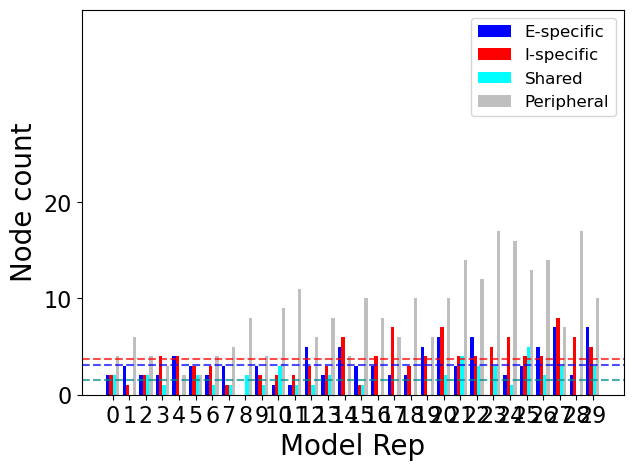

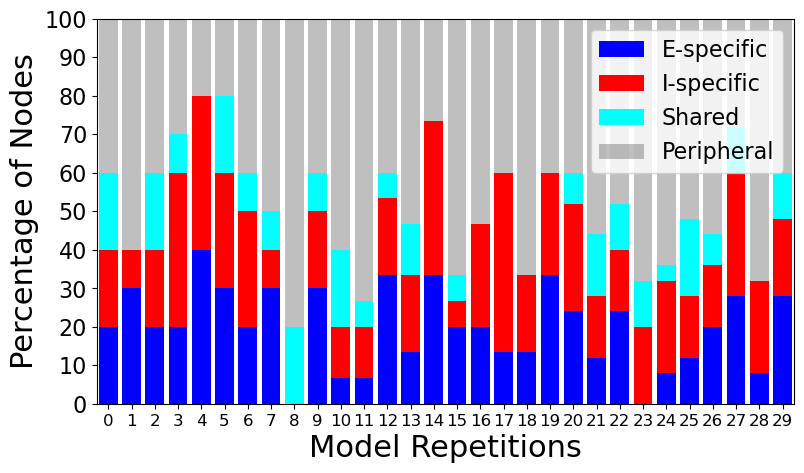

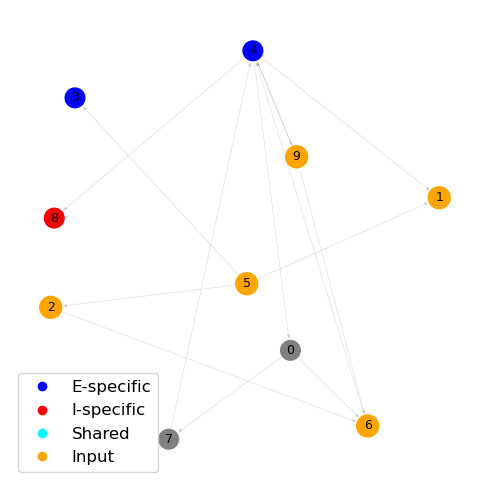

In [235]:
# len(Init_InpsNodes), len(Init_OutsNodes), len(Init_Graphs), len(Init_Wouts))

Init_rep_stats, Init_agg = node_specificity_analysis_allreps_v2(Init_Wouts,
    Init_Graphs,
    Init_InpsNodes,
    Init_OutsNodes,
    weight_thresh=0.03,
    best_rep=1, save=True, save_dir=DataDir, RandNet=False, InitNet=True)

## Connectivity Comparison

In [205]:
# print(len(rep_stats), rep_stats[0]['pct_E'])

def Classified_Node_Collector(stats):
    pct_Es=[]; pct_Is=[]; pct_Shareds=[]; pct_Periphs=[]
    for ii in range(len(stats)):
        pct_Es.append(stats[ii]['pct_E'])
        pct_Is.append(stats[ii]['pct_I'])
        pct_Shareds.append(stats[ii]['pct_shared'])
        pct_Periphs.append(stats[ii]['pct_periph'])
    return pct_Es, pct_Is, pct_Shareds, pct_Periphs

Init_pct_Es, Init_pct_Is, Init_pct_Shareds, Init_pct_Periphs = Classified_Node_Collector(Init_rep_stats)
PDNE_pct_Es, PDNE_pct_Is, PDNE_pct_Shareds, PDNE_pct_Periphs = Classified_Node_Collector(rep_stats)
Rand_pct_Es, Rand_pct_Is, Rand_pct_Shareds, Rand_pct_Periphs = Classified_Node_Collector(Rand_rep_stats)

print(len(Init_pct_Es), len(PDNE_pct_Es), Rand_pct_Es)

30 30 [23.333333333333332, 21.666666666666668, 25.0, 13.333333333333334, 20.0, 15.0, 15.0, 26.666666666666668, 18.333333333333332, 26.666666666666668, 23.333333333333332, 10.0, 23.333333333333332, 21.666666666666668, 26.666666666666668, 24.0, 18.0, 19.0, 19.0, 20.0, 23.0, 27.0, 22.0, 24.0, 19.0, 27.0, 26.0, 27.0, 24.0, 26.0]


C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\2752949392.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='% E Nodes', data=E_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\2752949392.py:28: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(x='Model', y='% E Nodes', data=E_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\2752949392.py:28: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Model', y='% E Nodes', data=E_df, scale='width', inner='quartile', palette=Colors)
C:\Users\genxm\AppData\Local\Temp\ipykernel_14076\2752949392.py:36: Futur

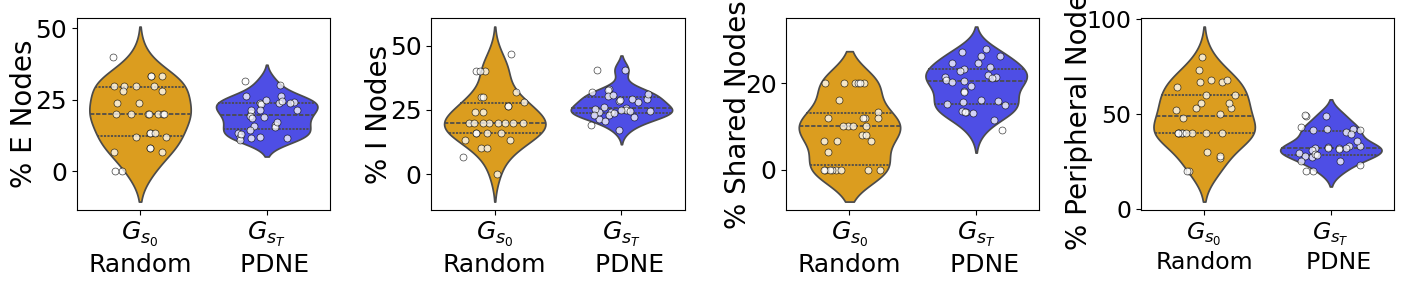

In [238]:
### Build DataFrames for classified node percentages
E_Init_df = pd.DataFrame({'% E Nodes': Init_pct_Es, 'Model': '$G_{s_{0}}$\nRandom'})
E_PDNE_df = pd.DataFrame({'% E Nodes': PDNE_pct_Es, 'Model': '$G_{s_{T}}$\n  PDNE'})
# E_Rand_df = pd.DataFrame({'% E Nodes': Rand_pct_Es, 'Model': 'Random'})
E_df = pd.concat([E_Init_df, E_PDNE_df], ignore_index=True)

I_Init_df = pd.DataFrame({'% I Nodes': Init_pct_Is, 'Model': '$G_{s_{0}}$\nRandom'})
I_PDNE_df = pd.DataFrame({'% I Nodes': PDNE_pct_Is, 'Model': '$G_{s_{T}}$\n  PDNE'})
# I_Rand_df = pd.DataFrame({'% I Nodes': Rand_pct_Is, 'Model': 'Random'})
I_df = pd.concat([I_Init_df, I_PDNE_df], ignore_index=True)

Sh_Init_df = pd.DataFrame({'% Shared': Init_pct_Shareds, 'Model': '$G_{s_{0}}$\nRandom'})
Sh_PDNE_df = pd.DataFrame({'% Shared': PDNE_pct_Shareds, 'Model': '$G_{s_{T}}$\n  PDNE'})
# Sh_Rand_df = pd.DataFrame({'% Shared': Rand_pct_Shareds, 'Model': 'Random'})
Sh_df = pd.concat([Sh_Init_df, Sh_PDNE_df], ignore_index=True)

Pe_Init_df = pd.DataFrame({'% Peripheral': Init_pct_Periphs, 'Model': '$G_{s_{0}}$\nRandom'})
Pe_PDNE_df = pd.DataFrame({'% Peripheral': PDNE_pct_Periphs, 'Model': '$G_{s_{T}}$\n  PDNE'})
# Pe_Rand_df = pd.DataFrame({'% Peripheral': Rand_pct_Periphs, 'Model': 'Random'})
Pe_df = pd.concat([Pe_Init_df, Pe_PDNE_df], ignore_index=True)

Colors = ["#faa700ff", "#3535feff", "#eb9bcff8"] 

### Plotting
plt.figure(figsize=(17, 2.5))

plt.subplot(1, 4, 1)
sns.violinplot(x='Model', y='% E Nodes', data=E_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y='% E Nodes', data=E_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
plt.xlabel('')
plt.ylabel('% E Nodes', fontsize=20, labelpad=-2)
plt.tick_params(axis='x', labelsize=18, labelbottom=True)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 4, 2)
sns.violinplot(x='Model', y='% I Nodes', data=I_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y='% I Nodes', data=I_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
plt.xlabel('')
plt.ylabel('% I Nodes', fontsize=20, labelpad=-2)
plt.tick_params(axis='x', labelsize=18, labelbottom=True)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 4, 3)
sns.violinplot(x='Model', y='% Shared', data=Sh_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y='% Shared', data=Sh_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
plt.xlabel('')
plt.ylabel('% Shared Nodes', fontsize=20, labelpad=-5)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 4, 4)
sns.violinplot(x='Model', y='% Peripheral', data=Pe_df, scale='width', inner='quartile', palette=Colors)
sns.stripplot(x='Model', y='% Peripheral', data=Pe_df, color='white', edgecolor='k', linewidth=0.5, jitter=0.25, alpha=0.75)
plt.xlabel('')
plt.ylabel('% Peripheral Nodes', fontsize=20, labelpad=-5)
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=17)

plt.subplots_adjust(wspace=0.4)
plt.savefig(f"{DataDir}/ClassifiedNodes_Comparison.svg")
plt.show()


## Threshold Sensitivity Analysis


Running threshold sensitivity across θ = [0.0075, 0.01, 0.02, 0.03, 0.05] ...

  θ = 0.0075

  θ = 0.01

  θ = 0.02

  θ = 0.03

  θ = 0.05

  THRESHOLD SENSITIVITY — NODE CLASSIFICATION
       θ           n_E           n_I           n_S           n_P    signs (mean)
------------------------------------------------------------------------
    0.01   19.0± 7.0   25.7± 8.1   23.3± 7.4   25.5±10.9    3/3 (med: 2/3)
    0.01   19.0± 7.1   25.9± 7.7   22.3± 7.4   26.4±11.3    3/3 (med: 3/3)
    0.02   19.0± 7.4   25.4± 7.6   19.6± 6.8   29.5±11.7    3/3 (med: 3/3)
    0.03   18.2± 7.1   25.2± 7.8   18.0± 6.5   32.2±12.1    3/3 (med: 2/3)
    0.05   17.5± 6.8   23.9± 7.7   15.4± 5.7   36.8±12.9    1/3 (med: 2/3)

  Percentage composition (mean ± std):
       θ            %E            %I       %Shared       %Periph
------------------------------------------------------------
    0.01   20.4± 5.5   27.5± 5.5   25.3± 6.0   26.7± 7.9
    0.01   20.5± 5.8   27.8± 5.0   24.0± 5.5   27.7± 8.2
   

d:\Work\TU-Berlin\Personal\work\Cell_DigitalTwin\PDNE-WilsonCowanNeuron\threshold_sensitivity.py:441: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



  Threshold sensitivity figure saved.


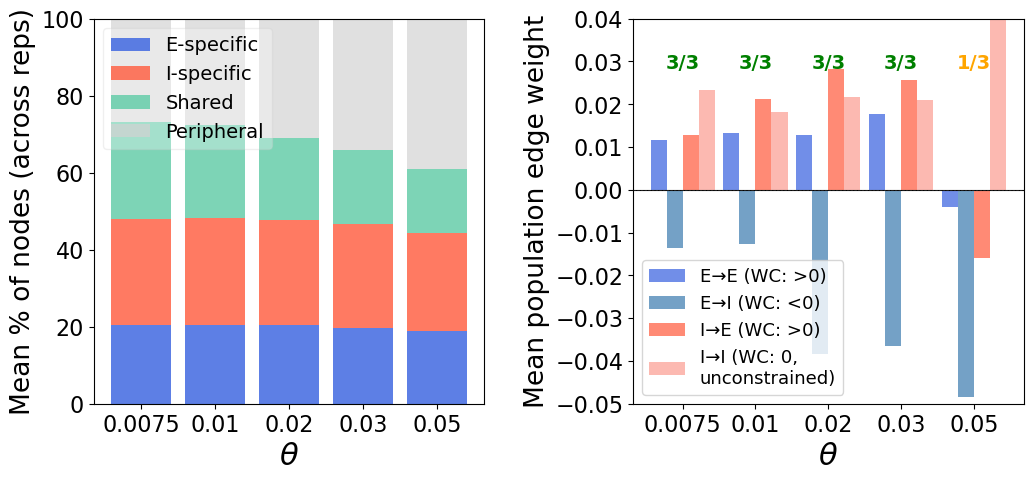


Running threshold sensitivity across θ = [0.0075, 0.01, 0.02, 0.03, 0.05] ...

  θ = 0.0075

  θ = 0.01

  θ = 0.02

  θ = 0.03

  θ = 0.05

  THRESHOLD SENSITIVITY — NODE CLASSIFICATION
       θ           n_E           n_I           n_S           n_P    signs (mean)
------------------------------------------------------------------------
    0.01   18.2± 6.2   18.9± 6.2   15.3± 5.8   27.6± 7.4    1/3 (med: 1/3)
    0.01   18.1± 6.2   19.0± 6.1   15.1± 5.7   27.8± 7.5    1/3 (med: 1/3)
    0.02   18.3± 6.2   18.8± 6.4   13.8± 5.5   29.1± 7.5    1/3 (med: 1/3)
    0.03   17.7± 6.1   17.9± 6.4   13.4± 5.3   31.0± 7.5    2/3 (med: 1/3)
    0.05   17.7± 6.3   17.5± 6.6   11.5± 4.9   33.3± 8.0    1/3 (med: 0/3)

  Percentage composition (mean ± std):
       θ            %E            %I       %Shared       %Periph
------------------------------------------------------------
    0.01   22.5± 4.6   23.5± 4.1   19.0± 4.5   35.1± 7.4
    0.01   22.4± 4.6   23.5± 4.1   18.7± 4.5   35.4± 7.5
   

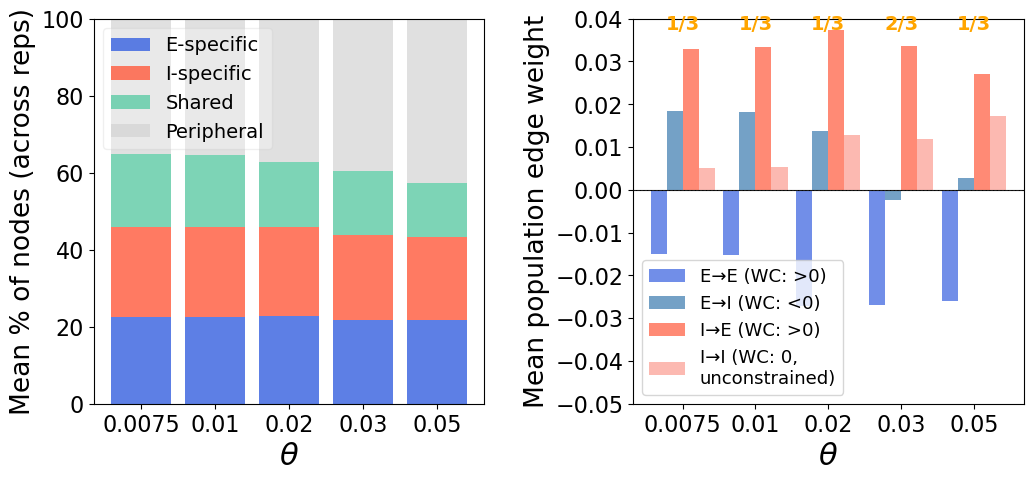

[{'thresh': 0.0075,
  'n_E': array([12., 12., 15.,  7., 12.,  8.,  9., 17., 14., 17., 16.,  9., 14.,
         14., 17., 29., 19., 19., 21., 21., 26., 27., 23., 23., 19., 27.,
         25., 26., 25., 22.]),
  'n_I': array([10., 10., 13., 14., 18., 13.,  9., 19., 15., 15., 16., 13., 13.,
         12., 14., 28., 23., 19., 22., 25., 29., 26., 25., 20., 20., 31.,
         23., 27., 25., 21.]),
  'n_S': array([ 6., 11.,  8., 14., 10., 14., 12.,  9., 12.,  8., 11., 12., 15.,
         13., 10., 12., 17., 18., 17., 12., 16., 17., 23., 26., 27., 18.,
         24., 19., 22., 27.]),
  'n_P': array([32., 27., 24., 25., 20., 25., 30., 15., 19., 20., 17., 26., 18.,
         21., 19., 31., 41., 44., 40., 42., 29., 30., 29., 31., 34., 24.,
         28., 28., 28., 30.]),
  'pct_E': array([20.        , 20.        , 25.        , 11.66666667, 20.        ,
         13.33333333, 15.        , 28.33333333, 23.33333333, 28.33333333,
         26.66666667, 15.        , 23.33333333, 23.33333333, 28.33333333,
     

In [207]:
from threshold_sensitivity import plot_threshold_sensitivity
 
plot_threshold_sensitivity(
    FM_tst_W_outs  = FM_tst_W_outs,
    FM_tst_Graphs  = FM_tst_Graphs,
    FM_tst_OutsNodes = FM_tst_OutsNodes,
    FM_train_ResStates = FM_train_ResStates,
    thresholds     = [0.0075, 0.01, 0.02, 0.03,0.05],
    save=True, save_dir=DataDir)

####Quick Threshold sensitivity for random networks
plot_threshold_sensitivity(
    FM_tst_W_outs  = All_W_outs_R,
    FM_tst_Graphs  = AllGraphs_list_R,
    FM_tst_OutsNodes = AllOutsNodes_list_R,
    FM_train_ResStates = All_Train_ResStates_R,
    thresholds     = [0.0075, 0.01, 0.02, 0.03,0.05],
    save=False, save_dir=DataDir)
    

## E-I Polarity and Path Length Asymmetry Analysis
### 1. of Evolved RC Net

Rep  0 | EI_exc= 54.5% IE_inh= 50.0% | NegFB=  0 ShortEI=  6 | PathEI=4.95 PathIE=5.03 | Mod=-255.613
Rep  1 | EI_exc= 50.0% IE_inh= 40.0% | NegFB=  0 ShortEI= 16 | PathEI=4.36 PathIE=4.28 | Mod=0.659
Rep  2 | EI_exc= 57.1% IE_inh= 33.3% | NegFB=  0 ShortEI=  1 | PathEI=4.35 PathIE=4.60 | Mod=-9.480
Rep  3 | EI_exc= 60.0% IE_inh= 71.4% | NegFB=  0 ShortEI=  0 | PathEI=4.89 PathIE=4.88 | Mod=0.039
Rep  4 | EI_exc= 20.0% IE_inh=100.0% | NegFB=  0 ShortEI=  1 | PathEI=2.76 PathIE=3.25 | Mod=-12.178
Rep  5 | EI_exc= 33.3% IE_inh= 77.8% | NegFB=  0 ShortEI=  7 | PathEI=4.49 PathIE=3.62 | Mod=-0.863
Rep  6 | EI_exc= 76.9% IE_inh= 60.0% | NegFB=  0 ShortEI= 10 | PathEI=4.75 PathIE=4.47 | Mod=-0.091
Rep  7 | EI_exc= 33.3% IE_inh= 40.0% | NegFB=  0 ShortEI= 14 | PathEI=4.31 PathIE=3.84 | Mod=0.255
Rep  8 | EI_exc= 42.9% IE_inh= 20.0% | NegFB=  0 ShortEI=  8 | PathEI=4.41 PathIE=4.04 | Mod=-154.525
Rep  9 | EI_exc= 50.0% IE_inh= 66.7% | NegFB=  0 ShortEI=  3 | PathEI=4.80 PathIE=4.88 | Mod=-1.77

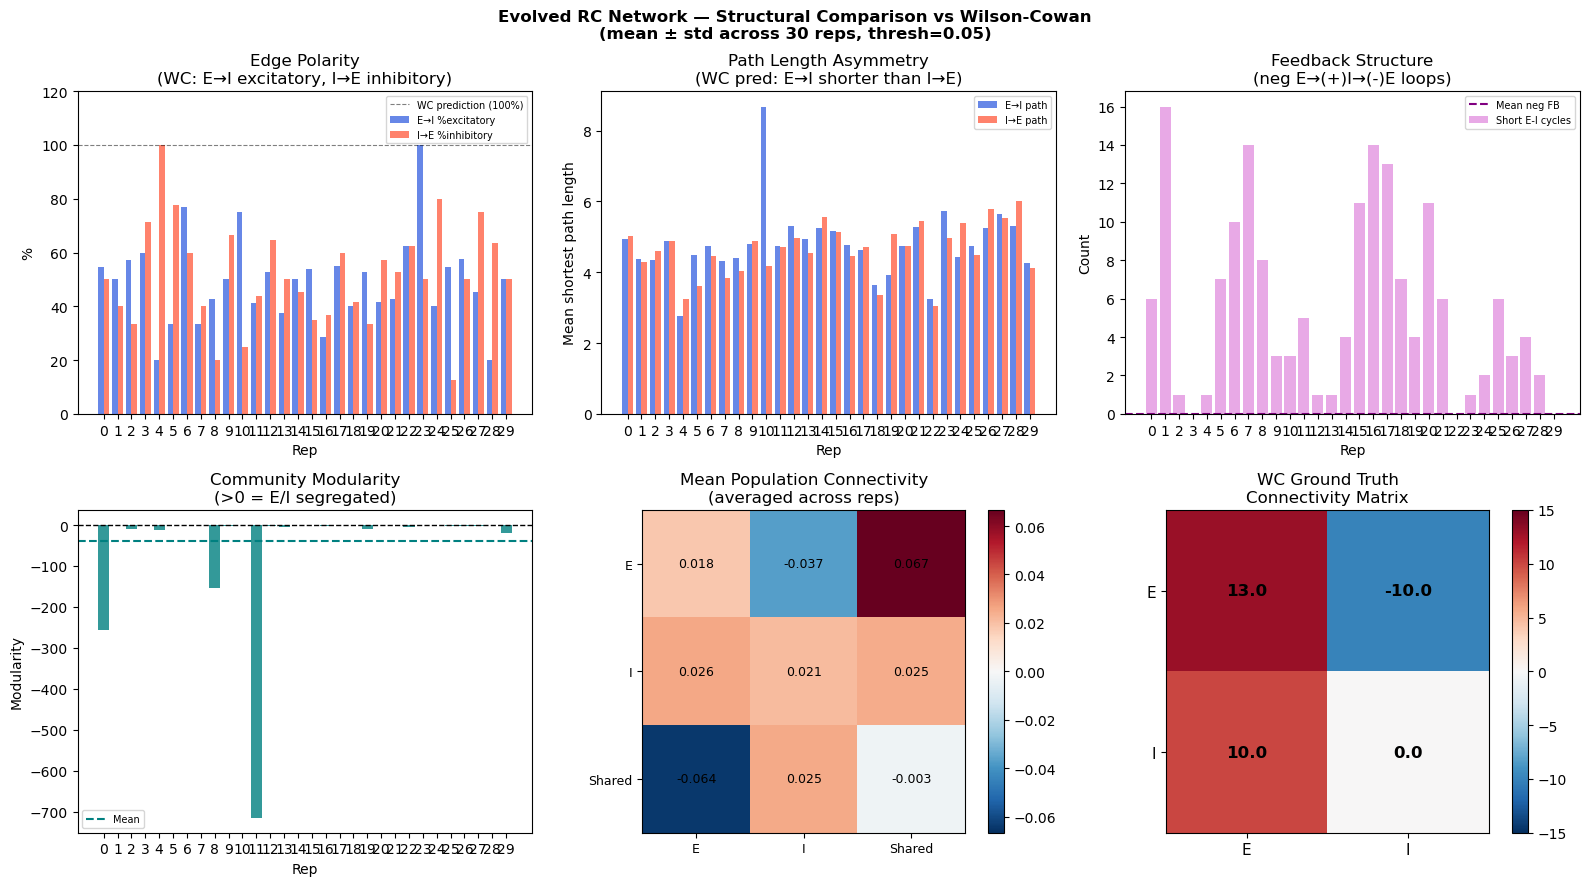

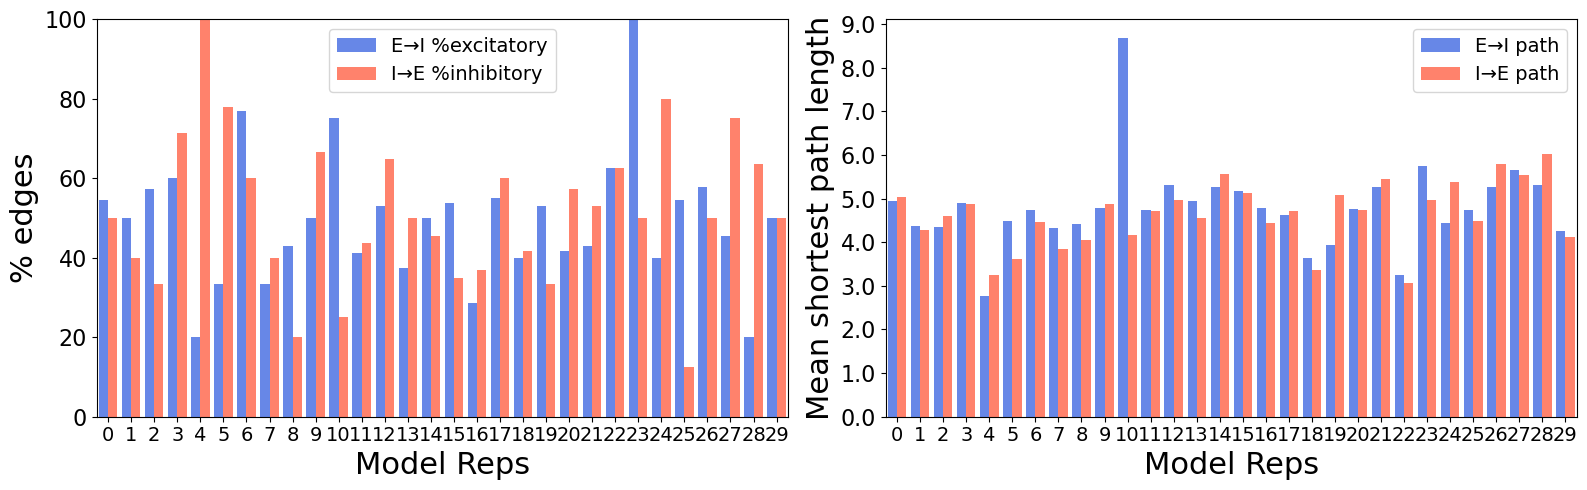

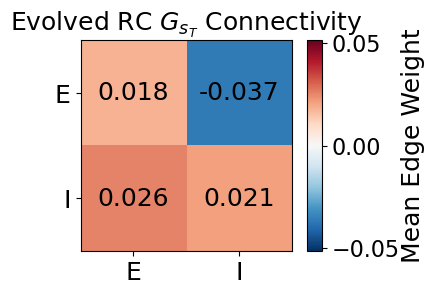

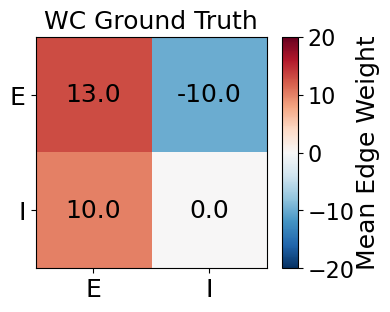

In [224]:
# Fallback for NetworkX < 3.1 — manual DFS with depth limit
def find_short_EI_cycles(G, E_nodes, I_nodes, max_len=4):
    short_EI = []
    for start in E_nodes | I_nodes:
        # DFS from each E/I node, stop at max_len
        stack = [(start, [start])]
        while stack:
            node, path = stack.pop()
            if len(path) > max_len:
                continue
            for nbr in G.successors(node):
                if nbr == path[0] and len(path) >= 2:
                    # Found a cycle back to start
                    if (any(n in E_nodes for n in path) and
                        any(n in I_nodes for n in path)):
                        short_EI.append(path[:])
                elif nbr not in path:
                    stack.append((nbr, path + [nbr]))
    # Deduplicate by canonical form
    seen = set()
    unique = []
    for c in short_EI:
        key = tuple(sorted(c))
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique

def structural_comparison_allreps(rep_stats, InpsNodes_all, weight_thresh=0.05, \
                                save=False, save_dir=None, IfRand=False, PathLenthPlot=True, InitPlot=False):
    """
    Runs WC structural comparison per rep and aggregates results.
    """
    n_reps = len(rep_stats)
    
    all_results = []
    for rp, rs in enumerate(rep_stats):
        G         = rs['G']
        A         = nx.to_numpy_array(G)
        node_list = rs['node_list']
        N         = rs['N_nodes']
        
        E_nodes = set(node_list[i] for i in rs['E_spec_idx'])
        I_nodes = set(node_list[i] for i in rs['I_spec_idx'])
        S_nodes = set(node_list[i] for i in rs['shared_idx'])
        inp_nodes = set(_flatten_int_nodes(InpsNodes_all[rp]))
        node_to_idx = {n: i for i, n in enumerate(node_list)}

        def mean_weight(src_set, tgt_set):
            edges = [A[node_to_idx[i], node_to_idx[j]] 
                     for i in src_set for j in tgt_set 
                     if i in node_to_idx and j in node_to_idx 
                     and A[node_to_idx[i], node_to_idx[j]] != 0]
            if not edges: return 0, 0, 0, 0
            exc = sum(1 for w in edges if w > 0)
            inh = sum(1 for w in edges if w < 0)
            return len(edges), 100*exc/len(edges), 100*inh/len(edges), np.mean(edges)

        # ── Edge census ───────────────────────────────────────────────────────
        ee_n, ee_exc, ee_inh, ee_w = mean_weight(E_nodes, E_nodes)
        ei_n, ei_exc, ei_inh, ei_w = mean_weight(E_nodes, I_nodes)
        ie_n, ie_exc, ie_inh, ie_w = mean_weight(I_nodes, E_nodes)
        ii_n, ii_exc, ii_inh, ii_w = mean_weight(I_nodes, I_nodes)
        se_n, se_exc, se_inh, se_w = mean_weight(S_nodes, E_nodes)
        si_n, si_exc, si_inh, si_w = mean_weight(S_nodes, I_nodes)

        # ── Signed negative feedback loops E→(+)I→(-)E ───────────────────────
        neg_fb = sum(1 for i in E_nodes for j in I_nodes
                     if (i in node_to_idx and j in node_to_idx and
                         A[node_to_idx[i], node_to_idx[j]] > 0 and
                         A[node_to_idx[j], node_to_idx[i]] < 0))

        # ── Short E-I cycles ──────────────────────────────────────────────────
        short_EI = find_short_EI_cycles(G, E_nodes, I_nodes, max_len=4)

        # ── Path lengths ──────────────────────────────────────────────────────
        paths_EI, paths_IE = [], []
        for e in E_nodes:
            for i in I_nodes:
                try: paths_EI.append(nx.shortest_path_length(G, e, i))
                except: pass
                try: paths_IE.append(nx.shortest_path_length(G, i, e))
                except: pass

        # ── Community alignment ───────────────────────────────────────────────
        communities = list(nx.community.greedy_modularity_communities(G))
        modularity  = nx.community.modularity(G, communities)

        # Best community alignment: does any community have E or I majority?
        ei_aligned = sum(1 for c in communities
                         if len(set(c) & E_nodes) > len(set(c) & I_nodes) * 1.5
                         or len(set(c) & I_nodes) > len(set(c) & E_nodes) * 1.5)

        result = {
            'rep'         : rp,
            'ee_w': ee_w, 'ei_w': ei_w, 'ie_w': ie_w, 'ii_w': ii_w,
            'ei_pct_exc'  : ei_exc,   # should be ~100% (WC: E→I excitatory)
            'ie_pct_inh'  : ie_inh,   # should be ~100% (WC: I→E inhibitory)
            'ii_pct_inh'  : ii_inh,   # WC: w_II=0, expect low
            'neg_fb_loops': neg_fb,
            'n_short_EI'  : len(short_EI),
            'mean_path_EI': np.mean(paths_EI) if paths_EI else np.nan,
            'mean_path_IE': np.mean(paths_IE) if paths_IE else np.nan,
            'path_asymm'  : (np.mean(paths_EI) - np.mean(paths_IE)) 
                             if paths_EI and paths_IE else np.nan,
            'modularity'  : modularity,
            'n_communities': len(communities),
            'ei_aligned_communities': ei_aligned,
        }
        all_results.append(result)
        print(f"Rep {rp:2d} | EI_exc={ei_exc:5.1f}% IE_inh={ie_inh:5.1f}% | "
              f"NegFB={neg_fb:3d} ShortEI={len(short_EI):3d} | "
              f"PathEI={result['mean_path_EI']:.2f} PathIE={result['mean_path_IE']:.2f} | "
              f"Mod={modularity:.3f}")

    # ── Aggregate ─────────────────────────────────────────────────────────────
    stat_keys = ['ei_pct_exc', 'ie_pct_inh', 'ii_pct_inh',
                 'neg_fb_loops', 'n_short_EI',
                 'mean_path_EI', 'mean_path_IE', 'path_asymm',
                 'modularity', 'ei_aligned_communities']

    print("\n" + "="*65)
    print("  STRUCTURAL SUMMARY vs WC PREDICTIONS (mean ± std, 10 reps)")
    print("="*65)
    wc_pred = {
        'ei_pct_exc'  : '~100% (E→I excitatory)',
        'ie_pct_inh'  : '~100% (I→E inhibitory)',
        'ii_pct_inh'  : '~0%   (w_II=0)',
        'neg_fb_loops': '>0    (E→(+)I→(-)E)',
        'n_short_EI'  : '>0    (short E-I cycles)',
        'mean_path_EI': 'short (fast excitation)',
        'mean_path_IE': 'longer (delayed inhibition)',
        'path_asymm'  : '>0    (EI longer than IE)',
        'modularity'  : '>0    (E/I segregated)',
        'ei_aligned_communities': '>0 (E or I dominant communities)',
    }
    agg_struct = {}
    for k in stat_keys:
        vals = np.array([r[k] for r in all_results if not np.isnan(r[k])])
        agg_struct[k] = {'mean': np.mean(vals), 'std': np.std(vals)}
        print(f"  {k:<28}: {np.mean(vals):7.2f} ± {np.std(vals):.2f}"
              f"  |  WC pred: {wc_pred[k]}")

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    # 1. E→I and I→E edge polarity across reps
    ax = axes[0]
    reps = np.arange(n_reps)
    ax.bar(reps - 0.2, [r['ei_pct_exc'] for r in all_results], 
           0.4, label='E→I %excitatory', color='royalblue', alpha=0.8)
    ax.bar(reps + 0.2, [r['ie_pct_inh'] for r in all_results], 
           0.4, label='I→E %inhibitory', color='tomato', alpha=0.8)
    ax.axhline(100, color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='WC prediction (100%)')
    ax.set_xlabel('Rep'); ax.set_ylabel('%')
    ax.set_title('Edge Polarity\n(WC: E→I excitatory, I→E inhibitory)')
    ax.set_xticks(reps); ax.legend(fontsize=7); ax.set_ylim(0, 120)

    # 2. Path length asymmetry
    ax = axes[1]
    ax.bar(reps - 0.2, [r['mean_path_EI'] for r in all_results],
           0.4, label='E→I path', color='royalblue', alpha=0.8)
    ax.bar(reps + 0.2, [r['mean_path_IE'] for r in all_results],
           0.4, label='I→E path', color='tomato', alpha=0.8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xlabel('Rep'); ax.set_ylabel('Mean shortest path length')
    ax.set_title('Path Length Asymmetry\n(WC pred: E→I shorter than I→E)')
    ax.set_xticks(reps); ax.legend(fontsize=7)

    # 3. Negative feedback loops
    ax = axes[2]
    ax.bar(reps, [r['neg_fb_loops'] for r in all_results],
           color='purple', alpha=0.8)
    ax.bar(reps, [r['n_short_EI'] for r in all_results],
           color='orchid', alpha=0.6, label='Short E-I cycles')
    ax.axhline(np.mean([r['neg_fb_loops'] for r in all_results]),
               color='purple', linestyle='--', linewidth=1.5, label='Mean neg FB')
    ax.set_xlabel('Rep'); ax.set_ylabel('Count')
    ax.set_title('Feedback Structure\n(neg E→(+)I→(-)E loops)')
    ax.set_xticks(reps); ax.legend(fontsize=7)

    # 4. Modularity
    ax = axes[3]
    ax.bar(reps, [r['modularity'] for r in all_results], color='teal', alpha=0.8)
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.axhline(np.mean([r['modularity'] for r in all_results]),
               color='teal', linestyle='--', linewidth=1.5, label='Mean')
    ax.set_xlabel('Rep'); ax.set_ylabel('Modularity')
    ax.set_title('Community Modularity\n(>0 = E/I segregated)')
    ax.set_xticks(reps); ax.legend(fontsize=7)

    # 5. Population connectivity matrix (mean across reps)
    ax = axes[4]
    pop_mat_all = np.zeros((3, 3, n_reps))
    for ri, rs_item in enumerate(rep_stats):
        G   = rs_item['G']
        A   = nx.to_numpy_array(G)
        nti = {n: i for i, n in enumerate(rs_item['node_list'])}
        pops = [
            set(rs_item['node_list'][i] for i in rs_item['E_spec_idx']),
            set(rs_item['node_list'][i] for i in rs_item['I_spec_idx']),
            set(rs_item['node_list'][i] for i in rs_item['shared_idx']),
        ]
        for pi, src in enumerate(pops):
            for pj, tgt in enumerate(pops):
                edges = [A[nti[i], nti[j]] for i in src for j in tgt
                         if i in nti and j in nti and A[nti[i], nti[j]] != 0]
                pop_mat_all[pi, pj, ri] = np.mean(edges) if edges else 0

    mean_pop_mat = np.nanmean(pop_mat_all, axis=2)
    vmax = np.abs(mean_pop_mat).max()
    im = ax.imshow(mean_pop_mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['E','I','Shared'], fontsize=9)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['E','I','Shared'], fontsize=9)
    ax.set_title('Mean Population Connectivity\n(averaged across reps)')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mean_pop_mat[i,j]:.3f}',
                    ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

    # 6. WC ground truth for comparison
    ax = axes[5]
    wc_matrix = np.array([[13.0, -10.0], [10.0, 0.0]])
    im2 = ax.imshow(wc_matrix, cmap='RdBu_r', vmin=-15, vmax=15)
    ax.set_xticks([0,1]); ax.set_xticklabels(['E','I'], fontsize=11)
    ax.set_yticks([0,1]); ax.set_yticklabels(['E','I'], fontsize=11)
    ax.set_title('WC Ground Truth\nConnectivity Matrix')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{wc_matrix[i,j]:.1f}',
                    ha='center', va='center', fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=ax)

    plt.suptitle('Evolved RC Network — Structural Comparison vs Wilson-Cowan\n'
                 f'(mean ± std across {n_reps} reps, thresh={weight_thresh})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes = axes.flatten()

    # 7. E→I and I→E edge polarity across reps
    ax = axes[0]
    reps = np.arange(n_reps)
    ax.bar(reps - 0.2, [r['ei_pct_exc'] for r in all_results], 
           0.4, label='E→I %excitatory', color='royalblue', alpha=0.8)
    ax.bar(reps + 0.2, [r['ie_pct_inh'] for r in all_results], 
           0.4, label='I→E %inhibitory', color='tomato', alpha=0.8)
    # ax.axhline(100, color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='WC prediction (100%)')
    ax.set_xlabel('Model Reps', fontsize=22); ax.set_ylabel('% edges', fontsize=22)
    # ax.set_title('Edge Polarity', fontsize=24)
    ax.set_xticks(reps); ax.legend(fontsize=14)
    ax.set_xlim(-0.5,29.5)
    ax.set_ylim(0, 100)
    ###increase y ticks fontsize
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_yticklabels(np.arange(0, 101, 20), fontsize=16)
    ax.set_xticklabels(reps, fontsize=14)

    # 8. Path length asymmetry
    if PathLenthPlot:
        ax = axes[1]
        ax.bar(reps - 0.2, [r['mean_path_EI'] for r in all_results],
            0.4, label='E→I path', color='royalblue', alpha=0.8)
        ax.bar(reps + 0.2, [r['mean_path_IE'] for r in all_results],
            0.4, label='I→E path', color='tomato', alpha=0.8)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_xlabel('Model Reps', fontsize=22); ax.set_ylabel('Mean shortest path length', fontsize=22)
        # ax.set_title('Path Length Asymmetry', fontsize=24)
        ax.set_xlim(-0.5,29.5)
        ax.set_xticks(reps); ax.legend(fontsize=14)
        ax.set_xticklabels(reps, fontsize=14)
        ax.set_yticks(np.arange(0, max([r['mean_path_EI'] for r in all_results]+[r['mean_path_IE'] for r in all_results])+1, 1))
        ax.set_yticklabels(np.arange(0, max([r['mean_path_EI'] for r in all_results]+[r['mean_path_IE'] for r in all_results])+1, 1), fontsize=16)
        
        plt.tight_layout()
        if save and save_dir is not None:
            if IfRand:
                plt.savefig(f"{save_dir}/Structural_Comparison_EI_Polarity_Path_Asymmetry_Rand.svg")
            else:
                plt.savefig(f"{save_dir}/Structural_Comparison_EI_Polarity_Path_Asymmetry.svg")
        plt.show()

    # 9. Population connectivity matrix (mean across reps)
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    
    pop_mat_all = np.zeros((2, 2, n_reps))
    for ri, rs_item in enumerate(rep_stats):
        G   = rs_item['G']
        A   = nx.to_numpy_array(G)
        nti = {n: i for i, n in enumerate(rs_item['node_list'])}
        pops = [
            set(rs_item['node_list'][i] for i in rs_item['E_spec_idx']),
            set(rs_item['node_list'][i] for i in rs_item['I_spec_idx']),
        ]
        for pi, src in enumerate(pops):
            for pj, tgt in enumerate(pops):
                edges = [A[nti[i], nti[j]] for i in src for j in tgt
                         if i in nti and j in nti and A[nti[i], nti[j]] != 0]
                pop_mat_all[pi, pj, ri] = np.mean(edges) if edges else 0

    mean_pop_mat = np.nanmean(pop_mat_all, axis=2)
    vmax = np.abs(mean_pop_mat).max()+0.015
    im = ax.imshow(mean_pop_mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks([0,1]); ax.set_xticklabels(['E','I'], fontsize=18)
    ax.set_yticks([0,1]); ax.set_yticklabels(['E','I'], fontsize=18)

    ax.set_title('Evolved RC $G_{s_{T}}$ Connectivity', fontsize=18)
    if InitPlot:
        ax.set_title('Inital RC $G_{s_{0}}$ Connectivity', fontsize=18)
    if IfRand:
        ax.set_title('ER Random RC Connectivity', fontsize=18)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{mean_pop_mat[i,j]:.3f}',
                    ha='center', va='center', fontsize=18)
   
    ##aligning colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="7%", pad=0.15)
    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Mean Edge Weight', rotation=90, labelpad=1, fontsize=18)
    plt.tight_layout()
    if save and save_dir is not None:
        if IfRand:
            plt.savefig(f"{save_dir}/Rand_Connectivity.svg")
        if InitPlot:
            plt.savefig(f"{save_dir}/PDNE_G0_Connectivity.svg")
        else:
            plt.savefig(f"{save_dir}/PDNE_GT_Connectivity.svg")
    plt.show()


    # 10. Ground Truth: WC Population connectivity matrix 
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    
    wc_matrix = np.array([[13.0, -10.0], [10.0, 0.0]])
    im2 = ax.imshow(wc_matrix, cmap='RdBu_r', vmin=-20, vmax=20)
    ax.set_xticks([0,1]); ax.set_xticklabels(['E','I'], fontsize=18)
    ax.set_yticks([0,1]); ax.set_yticklabels(['E','I'], fontsize=18)
    ax.set_title('WC Ground Truth', fontsize=18)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{wc_matrix[i,j]:.1f}',
                    ha='center', va='center', fontsize=18)
    
    ##aligning colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="7%", pad=0.15)
    cbar = plt.colorbar(im2, cax=cax)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Mean Edge Weight', rotation=90, labelpad=1, fontsize=18)
    plt.tight_layout()
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/WC_GroundTruth_Connectivity.svg")
    plt.show()    

    return all_results, agg_struct, mean_pop_mat


all_results, agg_struct, mean_pop_mat = structural_comparison_allreps(
    rep_stats, FM_tst_InpsNodes, weight_thresh=0.05, save=False, save_dir=DataDir)

### 2. of ER Random Net


Rep  0 | EI_exc=100.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=2.93 PathIE=5.16 | Mod=0.685
Rep  1 | EI_exc=100.0% IE_inh= 50.0% | NegFB=  0 ShortEI=  1 | PathEI=4.95 PathIE=3.56 | Mod=-2.657
Rep  2 | EI_exc= 40.0% IE_inh= 50.0% | NegFB=  0 ShortEI=  0 | PathEI=3.89 PathIE=4.40 | Mod=-14.105
Rep  3 | EI_exc=  0.0% IE_inh= 50.0% | NegFB=  0 ShortEI=  0 | PathEI=5.68 PathIE=5.13 | Mod=-2.680
Rep  4 | EI_exc= 50.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  1 | PathEI=5.65 PathIE=5.19 | Mod=0.425
Rep  5 | EI_exc= 83.3% IE_inh= 40.0% | NegFB=  1 ShortEI=  2 | PathEI=3.93 PathIE=3.67 | Mod=-64.947
Rep  6 | EI_exc= 50.0% IE_inh= 50.0% | NegFB=  0 ShortEI=  0 | PathEI=1.67 PathIE=3.38 | Mod=-1.669
Rep  7 | EI_exc= 55.6% IE_inh= 57.1% | NegFB=  0 ShortEI=  4 | PathEI=4.83 PathIE=4.73 | Mod=0.302
Rep  8 | EI_exc= 75.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  6 | PathEI=4.51 PathIE=4.09 | Mod=0.148
Rep  9 | EI_exc= 50.0% IE_inh= 71.4% | NegFB=  0 ShortEI=  0 | PathEI=5.21 PathIE=5.35 | Mod=-6.139
Re

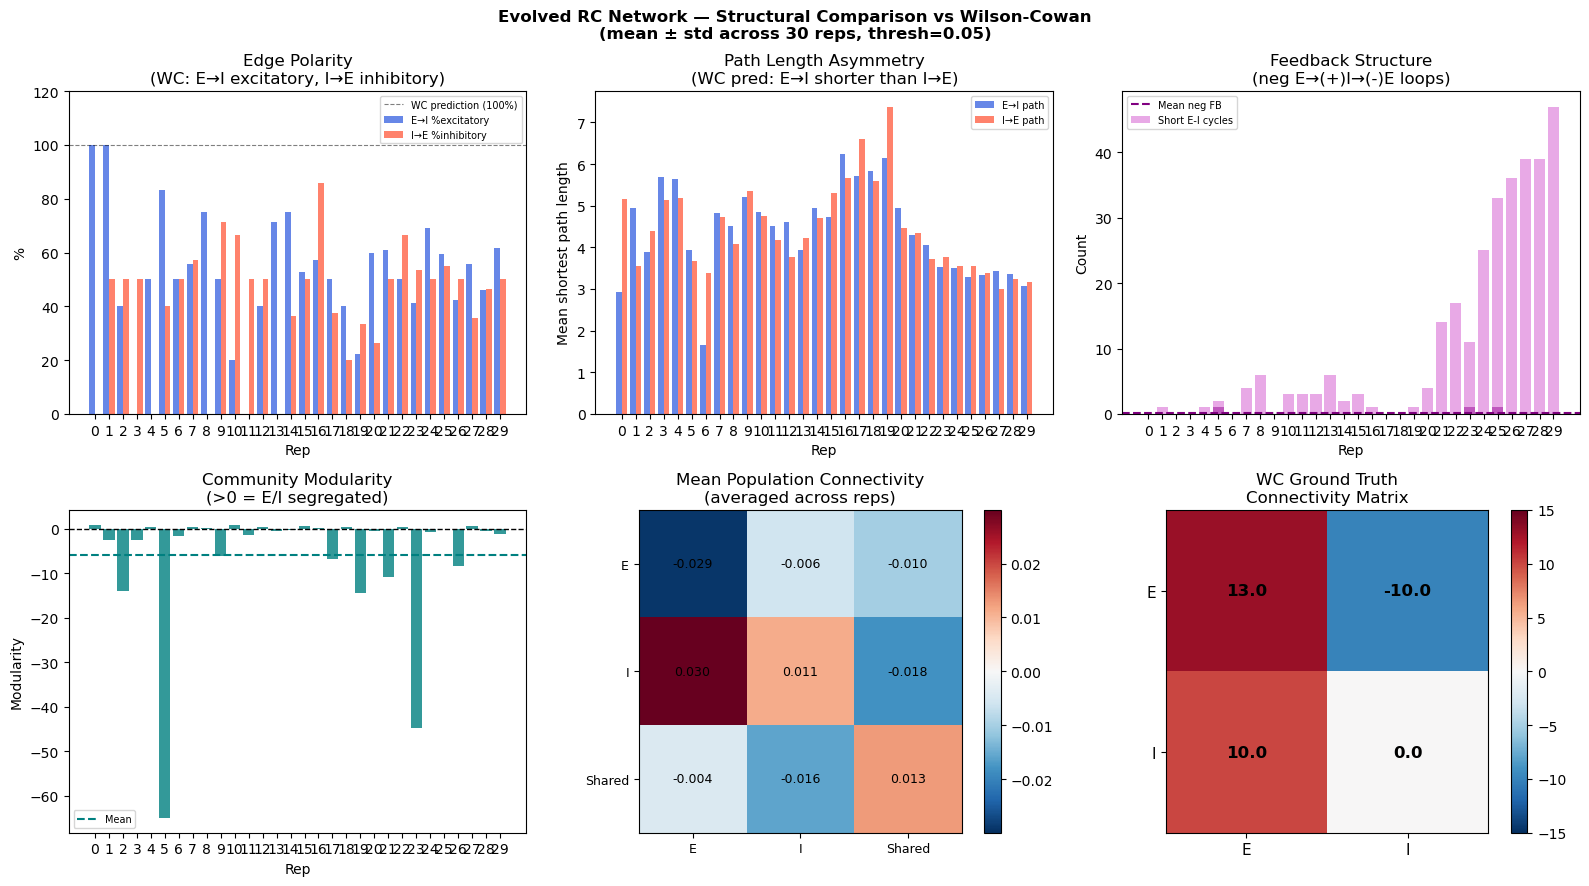

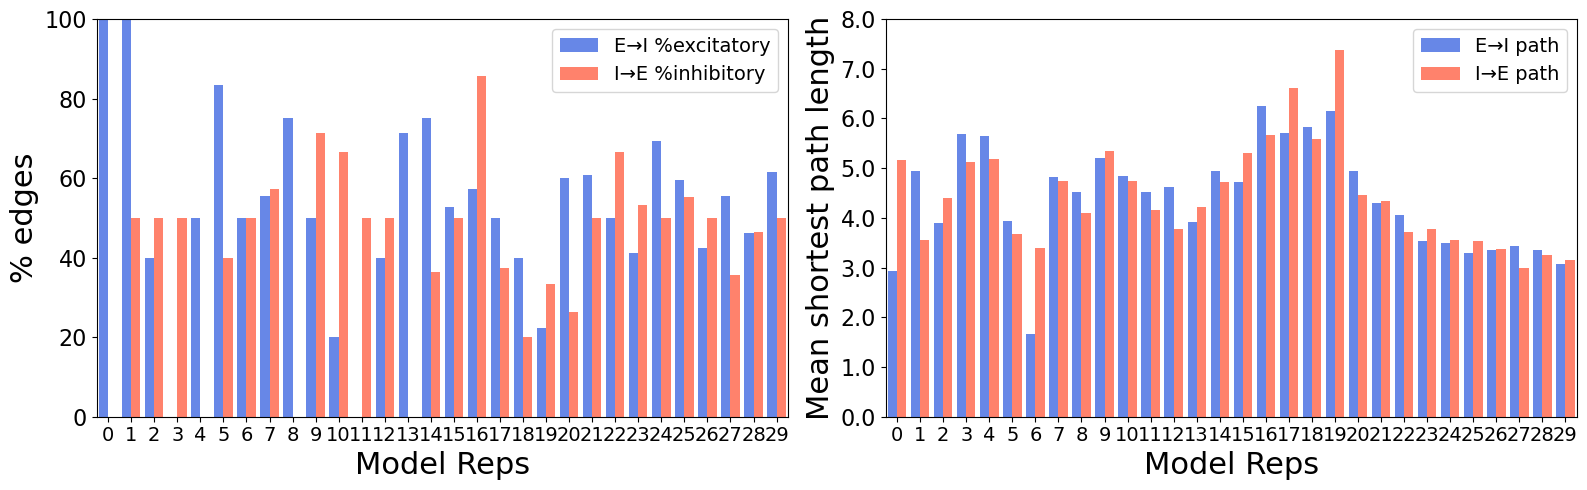

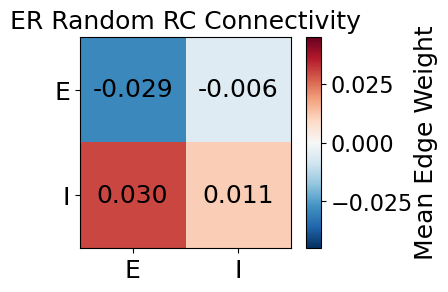

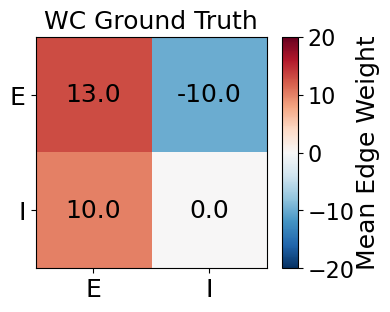

In [225]:
all_results, agg_struct, Rand_mean_pop_mat = structural_comparison_allreps(
    Rand_rep_stats, AllInpsNodes_list_R, weight_thresh=0.05, save=True, save_dir=DataDir, IfRand=True)

### 3. of Inital Rand Nets

Rep  0 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=nan PathIE=nan | Mod=0.055
Rep  1 | EI_exc=100.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=2.50 PathIE=nan | Mod=0.265
Rep  2 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=4.00 PathIE=nan | Mod=0.198
Rep  3 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  2 | PathEI=2.00 PathIE=2.00 | Mod=-2.367
Rep  4 | EI_exc=  0.0% IE_inh= 80.0% | NegFB=  0 ShortEI=  1 | PathEI=1.50 PathIE=1.50 | Mod=0.562
Rep  5 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=1.50 PathIE=nan | Mod=0.498
Rep  6 | EI_exc=100.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=1.50 PathIE=nan | Mod=0.311
Rep  7 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  1 | PathEI=2.00 PathIE=2.33 | Mod=0.621
Rep  8 | EI_exc=  0.0% IE_inh=  0.0% | NegFB=  0 ShortEI=  0 | PathEI=nan PathIE=nan | Mod=0.501
Rep  9 | EI_exc=  0.0% IE_inh= 50.0% | NegFB=  0 ShortEI=  0 | PathEI=nan PathIE=2.67 | Mod=-0.446
Rep 10 | EI_exc= 

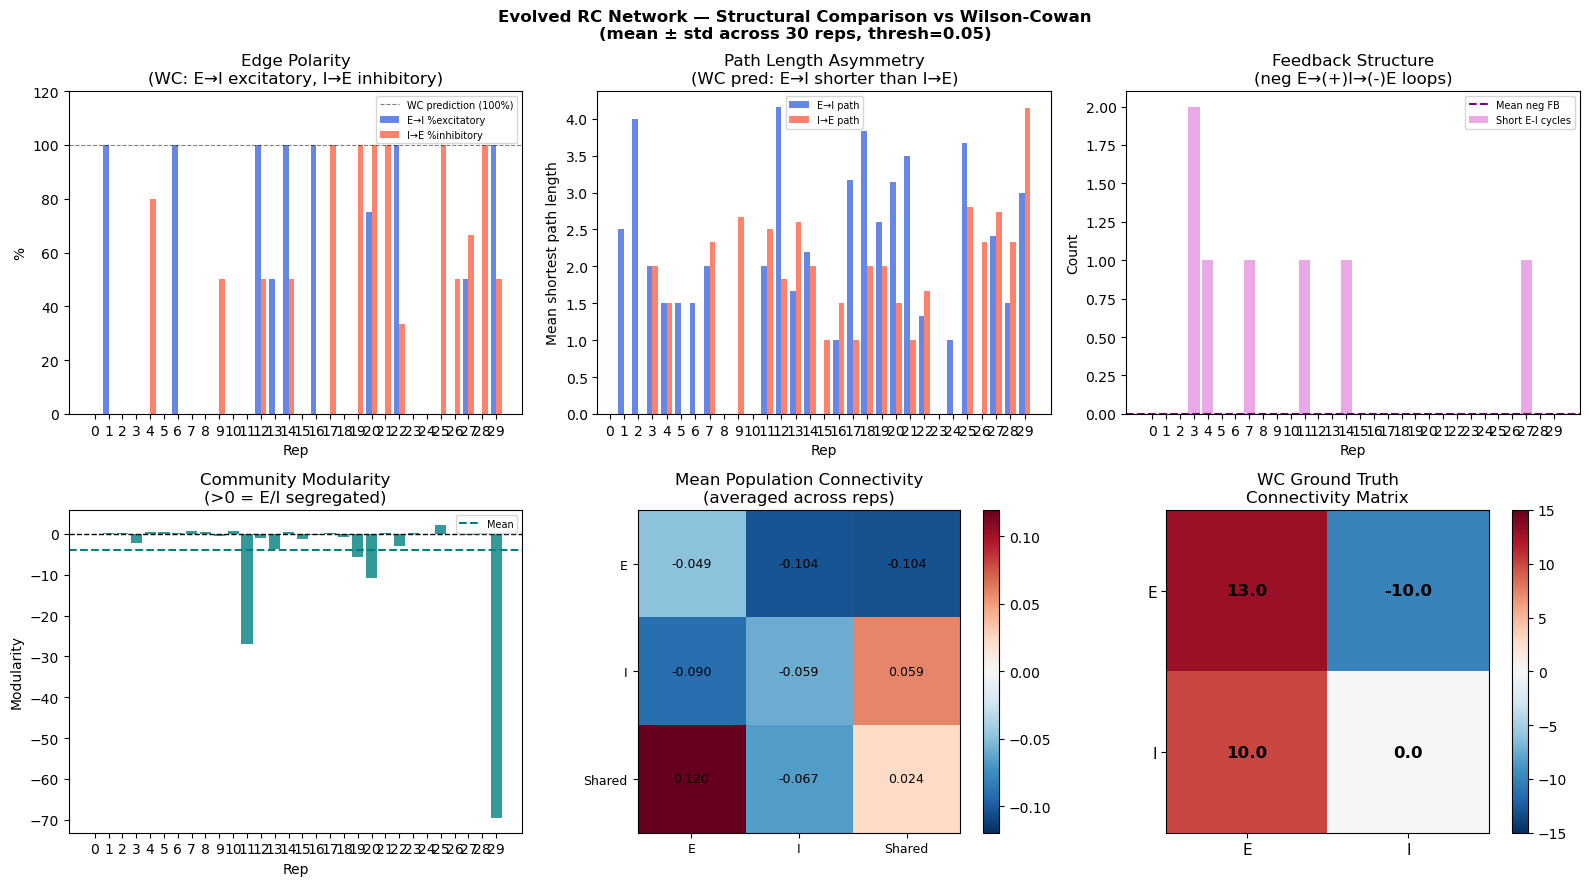

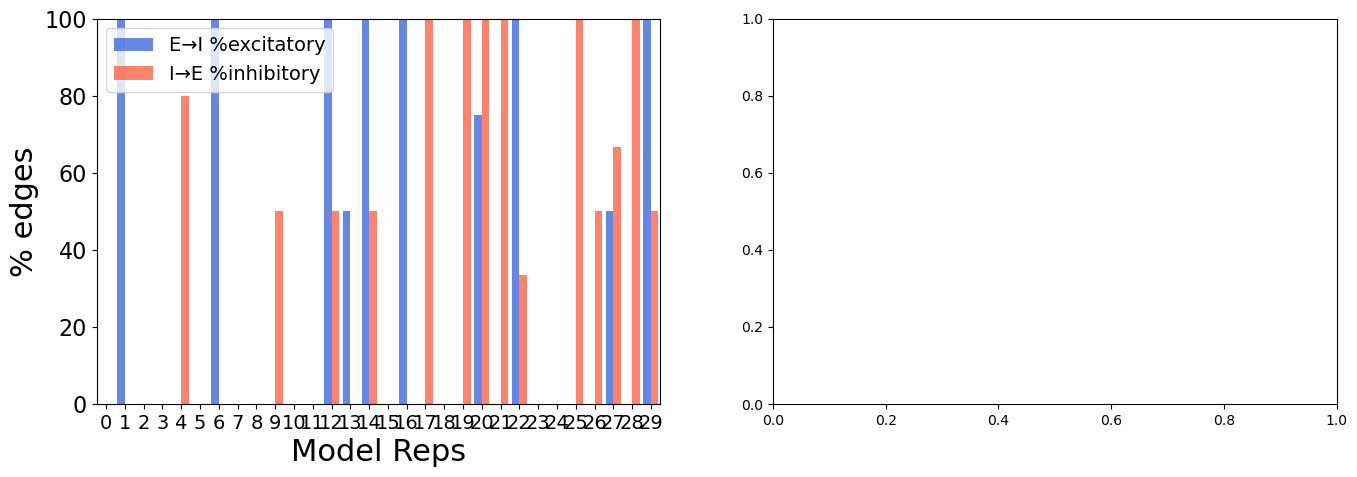

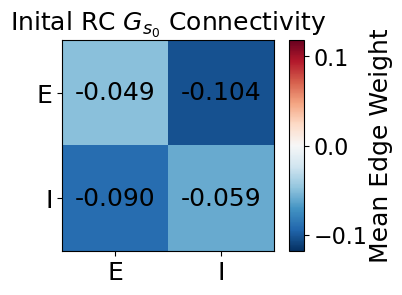

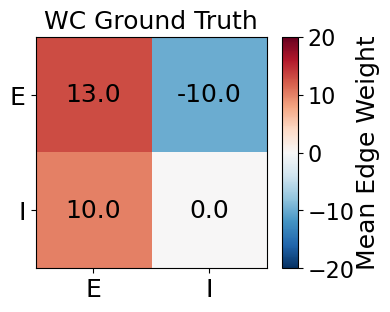

In [226]:
Init_all_results, Init_agg_struct, Init_mean_pop_mat = structural_comparison_allreps(
    Init_rep_stats, Init_InpsNodes, weight_thresh=0.05, save=True, save_dir=DataDir, IfRand=False, PathLenthPlot=False, InitPlot=True)

In [228]:
print(mean_pop_mat, Rand_mean_pop_mat, Init_mean_pop_mat)

[[ 0.01781731 -0.03658064]
 [ 0.02578719  0.02105386]] [[-0.02913141 -0.00596951]
 [ 0.02995308  0.01118872]] [[-0.04934945 -0.10363346]
 [-0.09031792 -0.05942702]]


In [230]:
def normalize_pm1(mat):
    return mat / np.max(np.abs(mat))

wc_matrix = np.array([[13.0, -10.0], [10.0, 0.0]])
wc_matrix_norm = normalize_pm1(wc_matrix)
mean_pop_mat_norm = normalize_pm1(mean_pop_mat)
Rand_mean_pop_mat_norm = normalize_pm1(Rand_mean_pop_mat)
Init_mean_pop_mat_norm = normalize_pm1(Init_mean_pop_mat)

print(wc_matrix_norm)
print(mean_pop_mat_norm)
print(Rand_mean_pop_mat_norm)
print(Init_mean_pop_mat_norm)

[[ 1.         -0.76923077]
 [ 0.76923077  0.        ]]
[[ 0.48706923 -1.        ]
 [ 0.70494095  0.57554643]]
[[-0.97256801 -0.19929528]
 [ 1.          0.37354163]]
[[-0.47619228 -1.        ]
 [-0.87151309 -0.5734347 ]]


## Reservoir States-based analysis 

In [19]:
# ── PCA of Reservoir States ──────────────────────────────────────────────────
# Requires: numpy, matplotlib, sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401


def pca_reservoir_states(
    ResStates,
    inp_idx        = 0,
    var_thresh     = 0.95,
    standardize    = True,
    Plot_analysis  = True,
    show_all_inps  = True,
    three_d_plot   = True,
    cmap           = 'viridis',
):
    """
    PCA dimensionality analysis of reservoir states.

    Parameters
    ----------
    ResStates    : np.ndarray, shape (Nodes, Inps, Time)
    inp_idx      : int   — which input slice to analyse in detail
    var_thresh   : float — cumulative-variance threshold to find n_min  [0,1]
    standardize  : bool  — z-score each node before PCA (recommended)
    show_all_inps: bool  — add a small-multiples panel for every input
    cmap         : str   — matplotlib colormap for the time-colour axis

    Returns
    -------
    results : dict
        'n_min'   – int,  minimal PCs needed to reach var_thresh
        'evr'     – (Nodes,)  explained-variance ratio per PC
        'cumev'   – (Nodes,)  cumulative explained variance
        'Z'       – (Time, n_min)  projected trajectory for inp_idx
        'pca'     – fitted sklearn PCA object  (n_components = max(n_min, 3))
        'X'       – (Time, Nodes)  (possibly standardised) data matrix
    """

    # ── 1. Slice & shape ─────────────────────────────────────────────────────
    N_nodes, N_inps, T_pts = ResStates.shape
    assert 0 <= inp_idx < N_inps, f"inp_idx must be in [0, {N_inps-1}]"

    X_raw = ResStates[:, inp_idx, :].T          # (Time, Nodes)

    if standardize:
        X = StandardScaler().fit_transform(X_raw)
    else:
        X = X_raw.copy()

    print(f"Data  : (Nodes={N_nodes}, Inps={N_inps}, Time={T_pts})")
    print(f"Slice : inp_idx={inp_idx}  →  X shape {X.shape}  "
          f"({'standardised' if standardize else 'raw'})")

    # ── 2. Full PCA → minimal dimensionality ─────────────────────────────────
    pca_full = PCA(n_components=N_nodes)
    pca_full.fit(X)

    evr   = pca_full.explained_variance_ratio_   # (N_nodes,)
    cumev = np.cumsum(evr)

    n_min = int(np.searchsorted(cumev, var_thresh)) + 1
    print(f"\nVar threshold {var_thresh*100:.0f}%  →  n_min = {n_min} PCs")
    print(f"Top-1: {evr[0]*100:.1f}%  |  "
          f"Top-2: {cumev[1]*100:.1f}%  |  "
          f"Top-3: {cumev[2]*100:.1f}%")

    # ── 3. Project onto n_min components (≥3 for 3-D plot) ───────────────────
    n_fit = max(n_min, 3)
    pca   = PCA(n_components=n_fit)
    Z     = pca.fit_transform(X)                 # (Time, n_fit)

    time_color = np.arange(T_pts)

    # ── 4. Scree + cumulative variance ───────────────────────────────────────
    if Plot_analysis:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        axes[0].bar(range(1, N_nodes+1), evr*100, color='steelblue', alpha=0.8)
        axes[0].axvline(n_min, color='red', ls='--', lw=1.5, label=f'n_min={n_min}')
        axes[0].set(xlabel='PC', ylabel='Explained variance (%)',
                    title=f'Scree plot  [inp={inp_idx}]')
        axes[0].legend()

        axes[1].plot(range(1, N_nodes+1), cumev*100, 'o-', color='steelblue', ms=4)
        axes[1].axhline(var_thresh*100, color='red', ls='--', lw=1.5,
                        label=f'{var_thresh*100:.0f}% threshold')
        axes[1].axvline(n_min, color='orange', ls='--', lw=1.5, label=f'n_min={n_min}')
        axes[1].set(xlabel='Number of PCs', ylabel='Cumulative variance (%)',
                    title='Cumulative explained variance', ylim=(0, 101))
        axes[1].legend()
        plt.suptitle(f'Minimal dimensionality  [inp={inp_idx}]', fontsize=12)
        plt.tight_layout(); plt.show()

    # ── 5. 2-D trajectory ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=time_color, cmap=cmap, s=12, zorder=3)
    ax.plot(Z[:, 0], Z[:, 1], lw=0.5, color='grey', alpha=0.5)
    ax.scatter(*Z[0, :2],  s=80, marker='o', color='lime',    zorder=5, label='start')
    ax.scatter(*Z[-1, :2], s=80, marker='X', color='crimson', zorder=5, label='end')
    plt.colorbar(sc, ax=ax, label='Time step')
    ax.set(xlabel=f'PC1 ({evr[0]*100:.1f}%)',
           ylabel=f'PC2 ({evr[1]*100:.1f}%)',
           title=f'State trajectory — 2D  [inp={inp_idx}]')
    ax.legend(); plt.tight_layout(); plt.show()

    # ── 6. 3-D trajectory ────────────────────────────────────────────────────
    if three_d_plot:
        fig  = plt.figure(figsize=(7, 6))
        ax3  = fig.add_subplot(111, projection='3d')
        # sc3  = ax3.scatter(Z[:, 0], Z[:, 1], Z[:, 2],
        #                 c=time_color, cmap=cmap, s=12)
        ax3.plot(Z[:, 0], Z[:, 1], Z[:, 2], lw=0.4, color='grey', alpha=0.5)
        ax3.scatter(*Z[0, :3],  s=80, marker='o', color='lime',    label='start')
        ax3.scatter(*Z[-1, :3], s=80, marker='X', color='crimson', label='end')
        fig.colorbar(sc3, ax=ax3, shrink=0.55, label='Time step')
        ax3.set(xlabel=f'PC1 ({evr[0]*100:.1f}%)',
                ylabel=f'PC2 ({evr[1]*100:.1f}%)',
                zlabel=f'PC3 ({evr[2]*100:.1f}%)',
                title=f'State trajectory — 3D  [inp={inp_idx}]')
        ax3.legend(); plt.tight_layout(); plt.show()

    # ── 7. All inputs — PC1 vs PC2 small multiples ───────────────────────────
    if show_all_inps:
        ncols = min(N_inps, 3)
        nrows = int(np.ceil(N_inps / ncols))
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5*ncols, 4*nrows),
                                 squeeze=False)
        for i in range(N_inps):
            ax = axes[i // ncols][i % ncols]
            Xi  = ResStates[:, i, :].T
            if standardize:
                Xi = StandardScaler().fit_transform(Xi)
            Zi  = PCA(n_components=2).fit_transform(Xi)
            tc  = np.arange(Zi.shape[0])
            ax.scatter(Zi[:, 0], Zi[:, 1], c=tc, cmap=cmap, s=8)
            ax.plot(Zi[:, 0], Zi[:, 1], lw=0.4, color='grey', alpha=0.4)
            ax.scatter(*Zi[0],  s=60, marker='o', color='lime')
            ax.scatter(*Zi[-1], s=60, marker='X', color='crimson')
            ax.set(title=f'inp={i}', xlabel='PC1', ylabel='PC2')
        # hide unused axes
        for j in range(N_inps, nrows*ncols):
            axes[j // ncols][j % ncols].set_visible(False)
        plt.suptitle('PC1–PC2 trajectories — all inputs', fontsize=13)
        plt.tight_layout(); plt.show()

    # ── 8. Return results ────────────────────────────────────────────────────
    return {
        'n_min' : n_min,
        'evr'   : evr,
        'cumev' : cumev,
        'Z'     : Z,   # trajectory in minimal space
        'pca'   : pca,
        'X'     : X,
    }


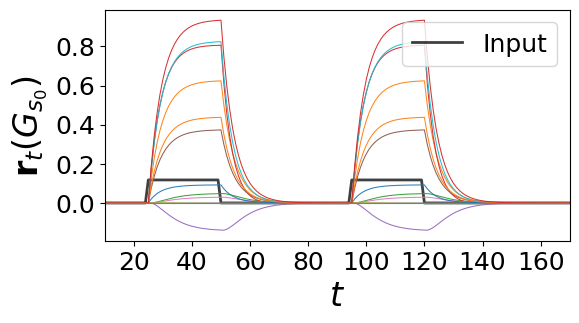

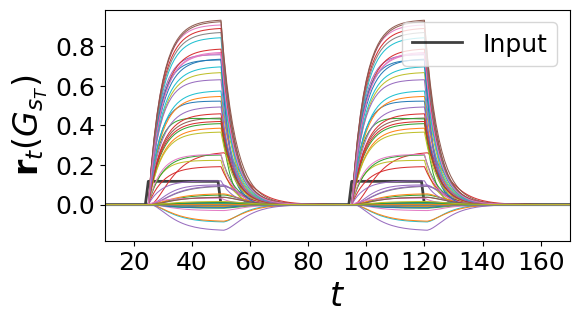

Data  : (Nodes=15, Inps=6, Time=200)
Slice : inp_idx=0  →  X shape (200, 15)  (standardised)

Var threshold 99%  →  n_min = 2 PCs
Top-1: 87.1%  |  Top-2: 99.4%  |  Top-3: 100.0%


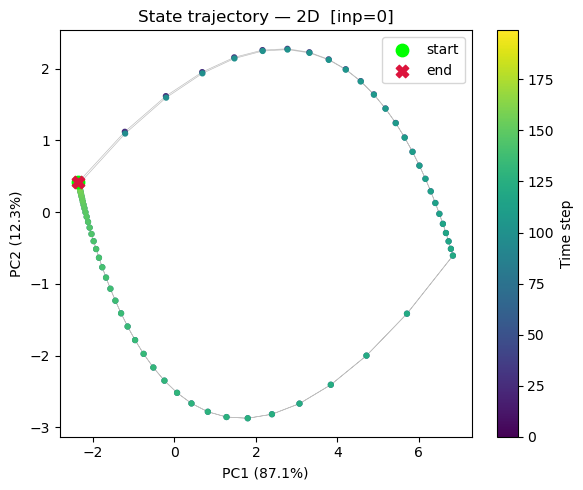


n_min  : 2
Z shape: (200, 3)
Data  : (Nodes=69, Inps=6, Time=200)
Slice : inp_idx=0  →  X shape (200, 69)  (standardised)

Var threshold 99%  →  n_min = 3 PCs
Top-1: 88.6%  |  Top-2: 98.8%  |  Top-3: 99.7%


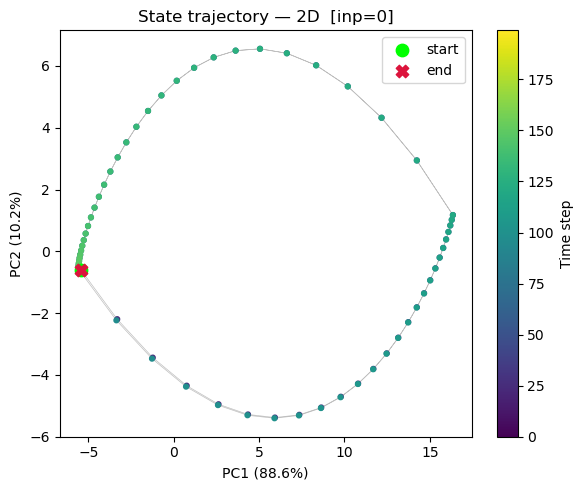


n_min  : 3
Z shape: (200, 3)


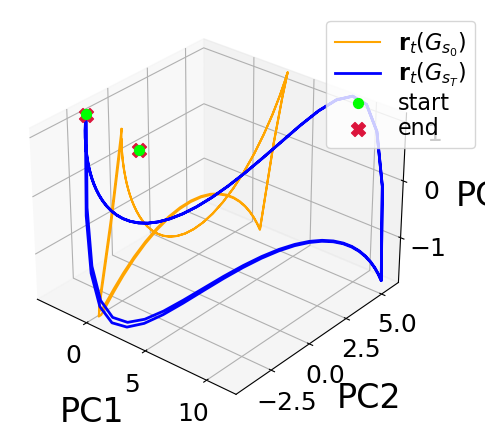

In [ ]:
####plot ResState for the first reservoir node, first batch and all time points

def plot_reservoir_states(Inp, ResStates_3D, batch_index, save_dir, save=False, ylabl='', savename=''):
    plt.figure(figsize=(6, 3))
    plt.plot(Inp/20, lw=2, color='k', alpha=0.75, label='Input')
    for i in range(len(ResStates_3D)):
        plt.plot(ResStates_3D[i][batch_index].T, lw=0.75, alpha=0.95)
    plt.xlabel('$t$', fontsize=24)
    plt.ylabel('$\mathbf{r}_t$'f'({ylabl})', fontsize=24)
    plt.xlim(10, 170)
    ###ticks fontsize
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(loc='best', fontsize=18)
    ###make y axis log scale
    if save and save_dir is not None:
        plt.savefig(f"{save_dir}/RC_State_TS_{savename}_Inp{batch_index}.svg")
    plt.show()

Model_rep=19; ##19, 13
Rand_rep = 14

Input_indx = 0 ##0, 1

plot_reservoir_states(Inps_test_O[Input_indx,0], All_Pred_ResStates[Model_rep][0], batch_index=Input_indx, \
                      save_dir=DataDir, save=True, ylabl='$G_{s_{0}}$', savename='Init')
plot_reservoir_states(Inps_test_O[Input_indx,0], FM_pred_ResStates[Model_rep], batch_index=Input_indx,\
                       save_dir=DataDir, save=True, ylabl='$G_{s_{T}}$', savename='Final')

# ── Usage ────────────────────────────────────────────────────────────────────
results = pca_reservoir_states(
    ResStates      = All_Pred_ResStates[Model_rep][0],
    inp_idx        = Input_indx,
    var_thresh     = 0.99,
    standardize    = True,
    Plot_analysis  = False,
    show_all_inps  = False,
    three_d_plot   = False,
    cmap           = 'viridis',
)

# Access results
print("\nn_min  :", results['n_min'])
print("Z shape:", results['Z'].shape)   # (Time, n_min)


results_f = pca_reservoir_states(
    ResStates      = FM_pred_ResStates[Model_rep],
    inp_idx        = Input_indx,
    var_thresh     = 0.99,
    standardize    = True,
    Plot_analysis  = False,
    show_all_inps  = False,
    three_d_plot   = False,
    cmap           = 'viridis',
)

# Access results
print("\nn_min  :", results_f['n_min'])
print("Z shape:", results_f['Z'].shape)   # (Time, n_min)


fig  = plt.figure(figsize=(5, 6))
ax3  = fig.add_subplot(111, projection='3d')

###for test network
ax3.plot(results['Z'][:, 0], results_f['Z'][:, 1], results_f['Z'][:, 2], lw=1.5, ls='-', \
         color='orange', alpha=1, label='$\mathbf{r}_t(G_{s_{0}})$')
ax3.plot(results_f['Z'][:, 0], results_f['Z'][:, 1], results_f['Z'][:, 2], lw=2,\
          color='blue', alpha=1, label='$\mathbf{r}_t(G_{s_{T}})$')

ax3.scatter(*results['Z'][0, :3], s=50, marker='o', color='lime', label='start')
ax3.scatter(*results['Z'][-1, :3], s=100, marker='X', color='crimson', label='end')

##for final network
ax3.scatter(*results_f['Z'][0, :3],  s=50, marker='o', color='lime')
ax3.scatter(*results_f['Z'][-1, :3], s=100, marker='X', color='crimson')
# ax3.set(xlabel=f'PC1', ylabel=f'PC2',zlabel=f'PC3')

ax3.set_xlim(-4,12); ax3.set_ylim(-4.5,6); ax3.set_zlim(-1.75,1.1) ##for inp0
# ax3.set_xlim(-3,14) ; ax3.set_ylim(-7,9)

ax3.set_xlabel('PC1', fontsize=24, labelpad=15)
ax3.set_ylabel('PC2', fontsize=24, labelpad=15)
ax3.set_zlabel('PC3', fontsize=24, labelpad=15)

# Tick labels
ax3.tick_params(axis='both', which='major', labelsize=18)
ax3.tick_params(axis='z', which='major', labelsize=18)

# ax3.set_xticks(fontsize=18)
###rotate the grid for better visualization
# ax3.view_init(elev=30, azim=40) ##for inp1
ax3.view_init(elev=30, azim=-50)
ax3.legend(loc='upper left', bbox_to_anchor=(0.75, 1.0), fontsize=16, labelspacing=0.1) 
plt.tight_layout()
# plt.savefig(f"{DataDir}/RC_State_PCA_Inp{Input_indx}.svg")
plt.show()